# Call Labeling Benchmark: keyword rules vs supervised ML vs budget LLMs vs System One models

**Question:** a support team wants every conversation labeled: why the customer reached out, what the agent did, how far it went. Which labeler gets it right, and what does each one cost in time and money at scale?

**Contenders**

| Family | Models | Needs labeled data? |
|---|---|---|
| Keyword rules | one regex per label | no |
| Supervised ML | TF-IDF + logistic regression, with a learning curve | yes (up to ~8,000 conversations) |
| Cheap, fast LLMs | Claude Haiku 4.5, Claude Haiku 5.5 (released 2026-10-07), GPT-6 Luna, Gemini 3.5 Flash-Lite: each provider's budget tier | no |
| System One | Jev 1.13 (TypeSafe, API), Laya (Convai, open weights, runs locally) | no |

**The rules every model plays by**

| Rule | Why |
|---|---|
| One conversation per call, all questions at once | How labeling runs in production. Jev and Laya take several typed questions natively; the LLMs return the same answers as one JSON object. |
| Identical question wording and option descriptions for everyone | Built once from a single `QUESTIONS` table, then rendered for each API. Nothing is tuned per model. |
| Only agent and customer lines are shown | The system action log is the ground truth; it is never in the transcript. |
| Structured outputs for every LLM | The "LLMs return broken JSON" argument is tested, not assumed: any invalid answer is logged and scored as wrong. |
| Provider-default reasoning, no tools | "Out of the box", same as the attrition run. |
| Questions and descriptions frozen before the test split is scored | The dev split is used only to prove the wiring. |
| Test set: all 1,000 usable ABCD test conversations | Big enough that confidence intervals separate models (the attrition run had 16 positives). 4 of the 1,004 carry an intent missing from ABCD's own ontology, so no option would be right. |

**The questions** use all three System One answer types: two `choice` questions (reason for contact, 10 options; specific intent, 55 options), four yes/no `noul` questions (identity verified, refund offered, promo code given, handed to another team), and one ordinal `score` (how far the agent went: information only, changed something, gave money back). Every answer has ground truth in the dataset, logged by the system rather than judged by an annotator.

**Sections:** 1 Load, 2 Questions and ground truth, 3 Scorers, 4 Keyword baseline, 5 Supervised baseline and learning curve, 6 Prompt and requests, 7 Models, 8 Smoke test, 9 Run, 10 Results, 11 Memorization probe, 12 Cost at scale, 13 Precision and recall, Figures, Caveats.

## 1. Load

Same pinned download as `01_explore.ipynb`, cached outside the repo.

In [1]:
%pip install -q pandas numpy scikit-learn matplotlib tiktoken typesafe-sdk anthropic openai google-genai

import gzip
import json
import os
import random
import re
import time
import urllib.request
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

ABCD_COMMIT = "6b8700ce67c6b37b062dd7a60abc76d7ef832a97"   # asappresearch/abcd, pinned
ABCD_FILES = ["data/abcd_v1.1.json.gz", "data/kb.json", "data/ontology.json"]
CACHE_DIR = Path.home() / ".cache" / "abcd" / ABCD_COMMIT
for file in ABCD_FILES:
    local_path = CACHE_DIR / file
    if not local_path.exists():
        local_path.parent.mkdir(parents=True, exist_ok=True)
        urllib.request.urlretrieve(f"https://raw.githubusercontent.com/asappresearch/abcd/{ABCD_COMMIT}/{file}", local_path)

with gzip.open(CACHE_DIR / "data/abcd_v1.1.json.gz") as f:
    abcd = json.load(f)
policy_actions = json.loads((CACHE_DIR / "data/kb.json").read_text())   # the 55 intents that have an action policy
print({split: len(conversations) for split, conversations in abcd.items()})


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


{'train': 8034, 'dev': 1004, 'test': 1004}


## 2. Questions and ground truth

`QUESTIONS` is the single source of truth: the wording and option descriptions every model sees. Option descriptions were written from the label names and the dataset's own ontology, before any model was run.

- **reason** (choice, 10): the scenario's `flow`.
- **intent** (choice, 55): the dataset's official 55 intents. For the two FAQ flows the scenario's `subflow` is a specific FAQ article (`boots_how_2`, `timing_1`); it maps to its intent by the name before the article number (`boots`, `timing`), as in the ABCD ontology.
- **four yes/no questions**: whether the matching action appears in the system log.
- **resolution** (score, 3 ordered levels) from the log: money back (refund or promo code) > changed something (order, account, password, purchase) > information only.

In [2]:
FLOW_DESCRIPTIONS = {
    "account_access": "Can't get into their account: forgot username or password, or two-factor authentication problems",
    "manage_account": "Wants to change account details or services: address, name, phone, payment method, added or removed services",
    "order_issue": "Problem with an existing order: unexpected fee, delivery time, payment method, quantity, or wants to change or cancel the order",
    "product_defect": "Received a faulty or wrong item and wants a return or refund, or asks about a refund",
    "purchase_dispute": "Disputes a charge or price: price dropped, competitor is cheaper, item out of stock, promo code failed, billed for something not bought or already returned",
    "shipping_issue": "Shipping problem: package status, change shipping details, missing package, or shipping cost",
    "single_item_query": "General question about one product (how it works, materials, sizing) with no order problem",
    "storewide_query": "General question about store-wide policies: pricing, timing, membership, or return policy",
    "subscription_inquiry": "Question about their subscription or membership: status, due date or amount, paying the bill, or extending it",
    "troubleshoot_site": "The website isn't working: slow, search results wrong, shopping cart or credit card not working",
}
FAQ_FLOWS = {"single_item_query", "storewide_query"}

def readable(name):
    return name.replace("_", " ").replace("2fa", "two-factor authentication")

# Intent options: ABCD's 55 official intents, each described as "<flow>: <intent>" straight from the ontology names
ontology = json.loads((CACHE_DIR / "data/ontology.json").read_text())
INTENT_FLOW = {intent: flow for flow, intents in ontology["intents"]["subflows"].items() for intent in intents}
INTENT_DESCRIPTIONS = {intent: f"{readable(flow)}: {readable(intent)}" for intent, flow in sorted(INTENT_FLOW.items())}

RESOLUTION_LEVELS = {   # ordered, lowest first; the index is the score
    "information_only": "Information only: the agent answered questions, looked things up or passed the issue on, but changed nothing and gave nothing",
    "changed_something": "Changed something: the agent updated an order or account, reset a password, or placed a purchase, but gave no money back",
    "money_back": "Money back: the agent issued a refund or gave the customer a promo code",
}
MONEY_ACTIONS = {"offer-refund", "promo-code"}
CHANGE_ACTIONS = {"update-order", "update-account", "make-password", "make-purchase"}

QUESTIONS = {
    "reason": {"type": "choice", "instructions": "Why did the customer contact the store?", "criteria": FLOW_DESCRIPTIONS},
    "intent": {"type": "choice", "instructions": "What specific request did the customer make?", "criteria": INTENT_DESCRIPTIONS},
    "identity_verified": {"type": "noul", "instructions": "Did the agent verify the customer's identity using their details (for example name, account ID, order ID or zip code)?",
                          "criteria": {"true": "The agent checked the customer's identity", "false": "No identity check was done"}},
    "refund_offered": {"type": "noul", "instructions": "Did the agent issue a refund to the customer?",
                       "criteria": {"true": "A refund was issued", "false": "No refund was issued (refunds may be mentioned, asked about or denied)"}},
    "promo_given": {"type": "noul", "instructions": "Did the agent give the customer a promo code?",
                    "criteria": {"true": "A promo code was given", "false": "No promo code was given"}},
    "handed_off": {"type": "noul", "instructions": "Did the agent pass the issue to another team (a manager, the purchasing department or the website team)?",
                   "criteria": {"true": "The issue was passed to another team", "false": "The agent handled it without passing it on"}},
    "resolution": {"type": "score", "instructions": "How far did the agent go for the customer?", "criteria": RESOLUTION_LEVELS},
}
NOUL_ACTIONS = {"identity_verified": "verify-identity", "refund_offered": "offer-refund",
                "promo_given": "promo-code", "handed_off": "notify-team"}
CHOICE_QUESTIONS = [name for name, question in QUESTIONS.items() if question["type"] == "choice"]
NOUL_QUESTIONS = [name for name, question in QUESTIONS.items() if question["type"] == "noul"]
SCORE_QUESTIONS = [name for name, question in QUESTIONS.items() if question["type"] == "score"]
print(f"{len(INTENT_DESCRIPTIONS)} intent options")

55 intent options


In [3]:
def conversation_text(conversation):
    # Agent and customer lines only: action lines are the ground truth and never reach a model
    return "\n".join(f"{speaker.capitalize()}: {text}" for speaker, text in conversation["original"] if speaker != "action")

def ground_truth(conversation):
    actions = {turn["targets"][2] for turn in conversation["delexed"] if turn["speaker"] == "action"}
    flow, subflow = conversation["scenario"]["flow"], conversation["scenario"]["subflow"]
    labels = {"reason": flow, "intent": subflow.split("_")[0] if flow in FAQ_FLOWS else subflow}   # FAQ article -> its intent
    labels.update({question: action in actions for question, action in NOUL_ACTIONS.items()})
    labels["resolution"] = 2 if actions & MONEY_ACTIONS else 1 if actions & CHANGE_ACTIONS else 0
    return labels

def build_split(split):
    rows = [{"convo_id": conversation["convo_id"], "text": conversation_text(conversation), **ground_truth(conversation)}
            for conversation in abcd[split]]
    frame = pd.DataFrame(rows).sort_values("convo_id").reset_index(drop=True)   # fixed order for every model
    # 33 conversations (4 in test) carry an intent missing from ABCD's own ontology (`status_questions`, `status_delivery_date`): no right option exists
    off_ontology = ~frame["intent"].isin(INTENT_DESCRIPTIONS)
    print(f"{split}: dropped {off_ontology.sum()} conversation(s) with an off-ontology intent: {sorted(frame.loc[off_ontology, 'intent'])}")
    return frame[~off_ontology].reset_index(drop=True)

train, dev, test = build_split("train"), build_split("dev"), build_split("test")
conversation_by_id = {conversation["convo_id"]: conversation for conversations in abcd.values() for conversation in conversations}

label_summary = {}
for question in NOUL_QUESTIONS:
    label_summary[question] = {"train positives": int(train[question].sum()), "test positives": int(test[question].sum()),
                               "test share": round(test[question].mean(), 3)}
display(pd.DataFrame(label_summary).T)
print("resolution levels in test:", test["resolution"].map(dict(enumerate(RESOLUTION_LEVELS))).value_counts().to_dict())

train: dropped 28 conversation(s) with an off-ontology intent: ['status_delivery_date', 'status_delivery_date', 'status_questions', 'status_questions', 'status_questions', 'status_questions', 'status_questions', 'status_questions', 'status_questions', 'status_questions', 'status_questions', 'status_questions', 'status_questions', 'status_questions', 'status_questions', 'status_questions', 'status_questions', 'status_questions', 'status_questions', 'status_questions', 'status_questions', 'status_questions', 'status_questions', 'status_questions', 'status_questions', 'status_questions', 'status_questions', 'status_questions']
dev: dropped 1 conversation(s) with an off-ontology intent: ['status_questions']
test: dropped 4 conversation(s) with an off-ontology intent: ['status_delivery_date', 'status_questions', 'status_questions', 'status_questions']


,train positives,test positives,test share
identity_verified,2661.0,343.0,0.343
refund_offered,632.0,68.0,0.068
promo_given,457.0,52.0,0.052
handed_off,440.0,72.0,0.072


resolution levels in test: {'information_only': 593, 'changed_something': 288, 'money_back': 119}


## 3. Scorers

One scorer per answer type, shared by every model. Bootstrap 95% intervals use the **same resamples for every model** (fixed seed), so intervals are directly comparable.

- **choice**: accuracy (headline) and macro-F1 (every option counts equally).
- **noul**: F2 on "yes" (rewards catching the rare positives, still punishes flagging everything), plus recall, precision and, for models that return a probability, AUC.
- **score**: exact accuracy and quadratic weighted kappa (partial credit for landing one level off).

**Invalid answers are always scored as wrong**, never dropped: a missing choice becomes `<invalid>`, a missing yes/no becomes the opposite of the truth, and a missing level becomes the level farthest from the truth. Each model's share of valid answers is reported next to its scores.

**A perfect score has a degenerate interval.** When a model gets every case right, every bootstrap resample is also perfect, so the interval is 1.00-1.00. That says the test set holds no counterexample, not that the model can't miss one; with 52 positives, a true miss rate of a few percent could easily go unseen.

In [4]:
from sklearn.metrics import accuracy_score, cohen_kappa_score, f1_score, roc_auc_score

BOOTSTRAP_RESAMPLES = 2000
RESAMPLE_INDEX = np.random.default_rng(SEED).integers(0, len(test), size=(BOOTSTRAP_RESAMPLES, len(test)))

def bootstrap_ci(metric, true_values, predicted_values):
    true_values, predicted_values = np.asarray(true_values), np.asarray(predicted_values)
    samples = [metric(true_values[index], predicted_values[index]) for index in RESAMPLE_INDEX]
    low, high = np.percentile(samples, [2.5, 97.5])
    return f"{low:.2f}-{high:.2f}"

def f2(true_values, predicted_values):
    tp = np.sum(true_values & predicted_values)
    return 5 * tp / max(5 * tp + 4 * np.sum(true_values & ~predicted_values) + np.sum(~true_values & predicted_values), 1)

def score_question(question, true_values, predicted_values, probabilities=None):
    question_type = QUESTIONS[question]["type"]
    if question_type == "choice":
        return {"accuracy": accuracy_score(true_values, predicted_values),
                "95% CI": bootstrap_ci(accuracy_score, true_values, predicted_values),
                "macro F1": f1_score(true_values, predicted_values, average="macro", zero_division=0)}
    if question_type == "noul":
        true_values, predicted_values = np.asarray(true_values, bool), np.asarray(predicted_values, bool)
        tp = int(np.sum(true_values & predicted_values))
        result = {"F2": f2(true_values, predicted_values), "95% CI": bootstrap_ci(f2, true_values, predicted_values),
                  "recall": tp / max(true_values.sum(), 1), "precision": tp / max(predicted_values.sum(), 1),
                  "TP": tp, "FN": int(np.sum(true_values & ~predicted_values)), "FP": int(np.sum(~true_values & predicted_values))}
        if probabilities is not None:
            result["AUC"] = roc_auc_score(true_values, probabilities)
        return result
    quadratic_kappa = lambda a, b: cohen_kappa_score(a, b, weights="quadratic", labels=list(range(len(RESOLUTION_LEVELS))))
    return {"accuracy": accuracy_score(true_values, predicted_values),
            "95% CI": bootstrap_ci(accuracy_score, true_values, predicted_values),
            "weighted kappa": quadratic_kappa(true_values, predicted_values)}

all_predictions, all_probabilities = {}, {}   # model -> question -> array over test rows

def score_model(model_name):
    return {question: score_question(question, test[question].values, all_predictions[model_name][question],
                                     all_probabilities.get(model_name, {}).get(question))
            for question in QUESTIONS}

## 4. Keyword baseline

The zero-training floor: one regular expression per yes/no label, written from the label names. `01_explore.ipynb` showed these keywords already separate the labels well, so any model has to beat `grep` to earn credit. There is no keyword version of the two choice questions (55 intents don't reduce to one regex each), so it's scored on the yes/no and resolution questions only.

In [5]:
KEYWORDS = {
    "identity_verified": r"verif|zip ?code|account id",
    "refund_offered": r"\brefund",
    "promo_given": r"\bpromo|\bcode\b|discount",
    "handed_off": r"manager|supervisor|department|team|escalat",
}
CHANGE_KEYWORDS = r"\bupdat|\bchang|\bcancel|\breset|new password|\border(?:ed)? (?:it|that|one)"

def keyword_predictions(frame):
    predictions = {question: frame["text"].str.contains(pattern, flags=re.IGNORECASE, regex=True).values
                   for question, pattern in KEYWORDS.items()}
    money = predictions["refund_offered"] | predictions["promo_given"]
    changed = frame["text"].str.contains(CHANGE_KEYWORDS, flags=re.IGNORECASE, regex=True).values
    predictions["resolution"] = np.where(money, 2, np.where(changed, 1, 0))
    return predictions

all_predictions["Keywords"] = keyword_predictions(test)
keyword_scores = {question: score_question(question, test[question].values, prediction)
                  for question, prediction in all_predictions["Keywords"].items()}
pd.DataFrame(keyword_scores).T

,F2,95% CI,recall,precision,TP,FN,FP,accuracy,weighted kappa
identity_verified,0.839572,0.81-0.87,0.915452,0.630522,314,29,184,NaN,NaN
refund_offered,0.735981,0.67-0.80,0.926471,0.403846,63,5,93,NaN,NaN
promo_given,0.675325,0.59-0.74,1.0,0.293785,52,0,125,NaN,NaN
handed_off,0.926893,0.89-0.96,0.986111,0.747368,71,1,24,NaN,NaN
resolution,NaN,0.55-0.61,NaN,NaN,NaN,NaN,NaN,0.58,0.382038


## 5. Supervised baseline and learning curve

TF-IDF (words and word pairs) + logistic regression, one model per question, trained on the train split. Neutral settings (no class weighting, 0.5 threshold), like the neutral RF in the attrition run.

The **learning curve** answers the practical question behind "just train a model": how many hand-labeled conversations does it take to match each zero-shot model? Each size is drawn 5 times at random; the curve shows the mean.

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

def train_tfidf(training_rows, question):
    model = make_pipeline(TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True),
                          LogisticRegression(max_iter=2000, C=4.0))
    return model.fit(training_rows["text"], training_rows[question])

def headline_metric(question, true_values, predicted_values):
    kind = QUESTIONS[question]["type"]
    if kind == "noul":
        return f2(np.asarray(true_values, bool), np.asarray(predicted_values, bool))
    return accuracy_score(true_values, predicted_values)

SUPERVISED = f"TF-IDF + LR ({len(train):,} labels)"
all_predictions[SUPERVISED], all_probabilities[SUPERVISED] = {}, {}
for question in QUESTIONS:
    model = train_tfidf(train, question)
    all_predictions[SUPERVISED][question] = model.predict(test["text"])
    if QUESTIONS[question]["type"] == "noul":
        all_probabilities[SUPERVISED][question] = model.predict_proba(test["text"])[:, 1]
pd.DataFrame(score_model(SUPERVISED)).T

,accuracy,95% CI,macro F1,F2,recall,precision,TP,FN,FP,AUC,weighted kappa
reason,0.953,0.94-0.97,0.952143,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
intent,0.913,0.90-0.93,0.901896,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
identity_verified,NaN,0.90-0.95,NaN,0.922131,0.918367,0.9375,315,28,21,0.981669,NaN
refund_offered,NaN,0.64-0.84,NaN,0.743034,0.705882,0.941176,48,20,3,0.978509,NaN
promo_given,NaN,0.72-0.90,NaN,0.820312,0.807692,0.875,42,10,6,0.996937,NaN
handed_off,NaN,0.75-0.91,NaN,0.835735,0.805556,0.983051,58,14,1,0.997815,NaN
resolution,0.92,0.90-0.94,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.85908


In [7]:
import warnings

LEARNING_CURVE_SIZES = [25, 50, 100, 200, 500, 1000, 2000, 4000, len(train)]
warnings.filterwarnings("ignore", message="The number of unique classes")   # tiny draws of the 55-way intent question
LEARNING_CURVE_DRAWS = 5
curve_rng = np.random.default_rng(SEED)
learning_curve_rows = []
curve_started = time.perf_counter()
for size in LEARNING_CURVE_SIZES:
    print(f"training on {size:,} labeled conversations ... ({time.perf_counter() - curve_started:.0f}s elapsed)", flush=True)
    for draw in range(LEARNING_CURVE_DRAWS if size < len(train) else 1):
        sample = train.iloc[curve_rng.choice(len(train), size=size, replace=False)]
        for question in QUESTIONS:
            if sample[question].nunique() < 2:   # tiny draws can miss a rare class entirely: count as a failed model
                learning_curve_rows.append({"size": size, "draw": draw, "question": question, "score": 0.0})
                continue
            predicted = train_tfidf(sample, question).predict(test["text"])
            learning_curve_rows.append({"size": size, "draw": draw, "question": question,
                                        "score": headline_metric(question, test[question].values, predicted)})
print(f"learning curve done in {time.perf_counter() - curve_started:.0f}s")
learning_curve = pd.DataFrame(learning_curve_rows).groupby(["question", "size"])["score"].mean().unstack("size")
learning_curve.round(3)

training on 25 labeled conversations ... (0s elapsed)


training on 50 labeled conversations ... (3s elapsed)


training on 100 labeled conversations ... (6s elapsed)


training on 200 labeled conversations ... (11s elapsed)


training on 500 labeled conversations ... (17s elapsed)


...

training on 2,000 labeled conversations ... (45s elapsed)


training on 4,000 labeled conversations ... (78s elapsed)


training on 8,006 labeled conversations ... (137s elapsed)


learning curve done in 162s


size,25,50,100,200,500,1000,2000,4000,8006
question,,,,,,,,,
handed_off,0.000,0.000,0.000,0.000,0.051,0.300,0.502,0.686,0.836
identity_verified,0.087,0.322,0.520,0.703,0.827,0.861,0.902,0.915,0.922
intent,0.111,0.174,0.282,0.472,0.704,0.816,0.863,0.898,0.913
promo_given,0.000,0.000,0.000,0.005,0.106,0.304,0.609,0.786,0.820
reason,0.369,0.508,0.735,0.819,0.913,0.937,0.943,0.951,0.953
refund_offered,0.000,0.000,0.000,0.007,0.072,0.214,0.432,0.609,0.743
resolution,0.641,0.643,0.678,0.735,0.807,0.854,0.888,0.906,0.920


## 6. One prompt, three request shapes

Everything is rendered from `QUESTIONS`:
- **Jev / Laya**: the transcript is `state`; each question is a typed `choice` / `noul` / `score` question with the same instructions and option descriptions.
- **LLMs**: the same instructions and descriptions as text, the transcript last (so the identical question block can be cached), and a JSON schema that only allows the listed options.

For score answers, Jev and Laya return a distribution over levels. Their docs warn that the expected value is unreliable as a magnitude, so the **most likely level** is used.

In [8]:
LLM_TASK = ("You are labeling a customer-service conversation between an agent and a customer of an online clothing store. "
            "Answer every question using only the conversation. Reply with a JSON object that has one key per question, "
            "using exactly one of the listed option keys as each value.")

def render_question_block():
    lines = []
    for name, question in QUESTIONS.items():
        lines.append(f"### {name}\n{question['instructions']}")
        if question["type"] == "noul":
            lines.append(f"- yes: {question['criteria']['true']}\n- no: {question['criteria']['false']}")
        else:
            lines.extend(f"- {key}: {description}" for key, description in question["criteria"].items())
        lines.append("")
    return "\n".join(lines)

LLM_QUESTION_BLOCK = f"{LLM_TASK}\n\n## Questions\n\n{render_question_block()}"

def llm_option_keys(name):
    question = QUESTIONS[name]
    return ["yes", "no"] if question["type"] == "noul" else list(question["criteria"])

LLM_SCHEMA = {
    "type": "object",
    "properties": {name: {"type": "string", "enum": llm_option_keys(name)} for name in QUESTIONS},
    "required": list(QUESTIONS),
    "additionalProperties": False,
}

def llm_prompt_parts(transcript):
    return LLM_QUESTION_BLOCK, f"## Conversation\n{transcript}\n"   # (identical cacheable prefix, per-call suffix)

def parse_llm_answers(raw_text):
    # Every answer checked against its option list; anything else -> None (invalid, scored as wrong)
    try:
        answers = json.loads(raw_text)
    except (json.JSONDecodeError, TypeError):
        return {name: None for name in QUESTIONS}
    parsed = {}
    for name, question in QUESTIONS.items():
        value = answers.get(name) if isinstance(answers, dict) else None
        if value not in llm_option_keys(name):
            parsed[name] = None
        elif question["type"] == "noul":
            parsed[name] = value == "yes"
        elif question["type"] == "score":
            parsed[name] = list(question["criteria"]).index(value)
        else:
            parsed[name] = value
    return parsed

def system_one_questions():
    # Plain JSON in Jev's wire format; Laya's Jev-compatible API takes the same shape
    rendered = {}
    for name, question in QUESTIONS.items():
        if question["type"] == "score":
            rendered[name] = {"type": "score", "instructions": question["instructions"], "criteria": list(question["criteria"].values())}
        else:
            rendered[name] = {"type": question["type"], "instructions": question["instructions"], "criteria": question["criteria"]}
    return rendered

SYSTEM_ONE_QUESTIONS = system_one_questions()

def parse_system_one_answers(answers):
    # answers: name -> {"choice"/"noul"/"score", "probabilities"}; returns (labels, probabilities for yes/no)
    labels, probabilities = {}, {}
    for name, question in QUESTIONS.items():
        answer = answers[name]
        if question["type"] == "choice":
            labels[name] = answer["choice"]
        elif question["type"] == "noul":
            probabilities[name] = float(answer["noul"])
            labels[name] = probabilities[name] >= 0.5
        else:
            level_probabilities = {int(level): p for level, p in answer["probabilities"].items()}
            labels[name] = max(level_probabilities, key=level_probabilities.get)
    return labels, probabilities

print(LLM_QUESTION_BLOCK[:1500], "...")
print(f"\nquestion block: {len(LLM_QUESTION_BLOCK):,} chars")
print("parser check:", parse_llm_answers('{"reason": "shipping_issue"}')["reason"], parse_llm_answers("not json")["reason"])

You are labeling a customer-service conversation between an agent and a customer of an online clothing store. Answer every question using only the conversation. Reply with a JSON object that has one key per question, using exactly one of the listed option keys as each value.

## Questions

### reason
Why did the customer contact the store?
- account_access: Can't get into their account: forgot username or password, or two-factor authentication problems
- manage_account: Wants to change account details or services: address, name, phone, payment method, added or removed services
- order_issue: Problem with an existing order: unexpected fee, delivery time, payment method, quantity, or wants to change or cancel the order
- product_defect: Received a faulty or wrong item and wants a return or refund, or asks about a refund
- purchase_dispute: Disputes a charge or price: price dropped, competitor is cheaper, item out of stock, promo code failed, billed for something not bought or already ret

## 7. The models

| Model | Tier | Reasoning (provider default) | Structured output |
|---|---|---|---|
| Claude Haiku 4.5 | cheap | none (no thinking by default) | `output_config.format` json_schema |
| Claude Haiku 5.5 | cheap | provider default (not set): adaptive thinking, effort medium | `output_config.format` json_schema |
| GPT-6 Luna | cheap | provider default (not set) | `text.format` json_schema, strict |
| Gemini 3.5 Flash-Lite | cheap | provider default (not set) | `response_json_schema` |
| Jev 1.13 | System One API | n/a (calibrated probabilities) | typed answers |
| Laya (English, 512) | System One, local | n/a | typed answers |
| Laya (English, 1,024) | System One, local | n/a | typed answers, longer budget |

- **Why the cheap tier.** Labeling is a high-volume job, so the realistic LLM competitor for a System One model is each provider's budget model, not its flagship. The mid-tier models from the attrition run (Claude Sonnet 5, GPT-6 Sol, Gemini 3.8 Flash) stay wired in behind `INCLUDE_MID_TIER` for a later run.
- **Prices** are $ per 1M tokens from each provider's pricing page (checked 2026-09-28): Haiku 4.5 $1 / $0.10 cache read / $1.25 cache write / $5 output; Haiku 5.5 $0.10 / $0.01 / $0.125 / $0.50 (its rate for prompts up to 100k tokens; checked 2026-10-08); GPT-6 Luna $0.10 / $0.01 / $0.125 / $0.50; Gemini 3.5 Flash-Lite $0.30 / $0.03 / none / $2.50.
- **Reasoning is left at each provider's default by not setting it**, so "out of the box" means exactly what ships.
- **Caching**: the ~2k-token question block is identical on every call. GPT-6 gets an explicit breakpoint before the transcript; Gemini caches implicitly. Haiku 4.5's minimum cacheable prompt is 4,096 tokens, so it can't cache this prefix; that's a real cost of Haiku here, not a setup mistake.
- **Laya runs twice.** The English checkpoint's default budget is 512 tokens, about 320 of them for the transcript, so the longest ~15% of conversations are cut. The second run gives it 1,024 tokens (its documented override). The option list shares a separate budget, which the 55-option intent question will strain; Laya's own docs list many-option questions as a weakness.
- **Laya's cost** is $0 per call on your own GPU; hardware and power aren't counted, same as the local model in the attrition run.
- **No tools or web search** for any model; OpenAI calls use `store=False`.

In [9]:
import csv
import hashlib
from dataclasses import asdict, dataclass, fields
from datetime import datetime, timezone

import anthropic
import openai
from google import genai
from google.genai import types as genai_types
from typesafe_sdk import TypeSafeClient

JEV_MODEL = "jev-1.13.0"   # pinned, not jev-latest
MAX_OUTPUT_TOKENS = 16_000

# provider picks the caller. reasoning: the setting passed, or None = parameter omitted (provider default).
MODELS = {
    "Claude Haiku 4.5":      {"provider": "anthropic", "model_id": "claude-haiku-4-5", "key_env": "CLAUDE_KEY", "reasoning": None,
                              "price": {"input": 1.00, "cached_input": 0.10, "cache_write": 1.25, "output": 5.00}},
    "Claude Haiku 5.5":      {"provider": "anthropic", "model_id": "claude-haiku-5-5", "key_env": "CLAUDE_KEY", "reasoning": None,
                              "price": {"input": 0.10, "cached_input": 0.01, "cache_write": 0.125, "output": 0.50}},
    "GPT-6 Luna":            {"provider": "openai", "model_id": "gpt-6-luna", "key_env": "GPT_KEY", "reasoning": None,
                              "price": {"input": 0.10, "cached_input": 0.01, "cache_write": 0.125, "output": 0.50}},
    "Gemini 3.5 Flash-Lite": {"provider": "google", "model_id": "gemini-3.5-flash-lite", "key_env": "GEM_KEY", "reasoning": None,
                              "price": {"input": 0.30, "cached_input": 0.03, "cache_write": 0.00, "output": 2.50}},
    "Jev":                   {"provider": "typesafe", "model_id": JEV_MODEL, "key_env": "JEV_KEY", "reasoning": None,
                              "price": {"input": 0.042, "cached_input": 0.042, "cache_write": 0.00, "output": 0.00}},
    "Laya (512)":            {"provider": "laya", "model_id": "convaiinnovations/laya", "key_env": None, "reasoning": None, "max_len": None,
                              "price": {"input": 0.0, "cached_input": 0.0, "cache_write": 0.0, "output": 0.0}},
    "Laya (1,024)":          {"provider": "laya", "model_id": "convaiinnovations/laya", "key_env": None, "reasoning": None, "max_len": 1024,
                              "price": {"input": 0.0, "cached_input": 0.0, "cache_write": 0.0, "output": 0.0}},
}
# The attrition run's mid-tier models, same settings as there. Off to keep this run cheap.
MID_TIER_MODELS = {
    "Claude Sonnet 5":  {"provider": "anthropic", "model_id": "claude-sonnet-5", "key_env": "CLAUDE_KEY",
                         "reasoning": {"thinking": {"type": "adaptive"}, "effort": "high"},
                         "price": {"input": 2.00, "cached_input": 0.20, "cache_write": 2.50, "output": 10.00}},
    "GPT-6 Sol":        {"provider": "openai", "model_id": "gpt-6-sol", "key_env": "GPT_KEY", "reasoning": "medium",
                         "price": {"input": 2.00, "cached_input": 0.20, "cache_write": 2.50, "output": 10.00}},
    "Gemini 3.8 Flash": {"provider": "google", "model_id": "gemini-3.8-flash", "key_env": "GEM_KEY", "reasoning": "medium",
                         "price": {"input": 0.75, "cached_input": 0.075, "cache_write": 0.00, "output": 3.75}},
}
INCLUDE_MID_TIER = False
if INCLUDE_MID_TIER:
    MODELS.update(MID_TIER_MODELS)
# Laya runs locally on the GPU (RTX 5070 Ti here); weights pinned to one Hugging Face revision
LAYA_REVISION = "55cf4c4ebb4ebe31b2550e8bdf3bd21b99753851"
INCLUDE_LAYA = True
if not INCLUDE_LAYA:
    for model_name in ["Laya (512)", "Laya (1,024)"]:
        MODELS.pop(model_name)

@dataclass
class CallRecord:
    model: str
    convo_id: int
    variant: str                           # "original" or "perturbed" (memorization probe)
    raw_answer: str = ""
    answers: str = ""                      # JSON: question -> parsed label (None = invalid)
    probabilities: str = ""                # JSON: yes/no question -> P(yes), System One models only
    invalid_answers: int = 0
    latency_s: float = 0.0
    uncached_input_tokens: int = 0
    cached_input_tokens: int = 0
    cache_write_tokens: int = 0
    output_tokens: int = 0                 # includes reasoning tokens (billed as output)
    reasoning_tokens: int = 0
    cost_usd: float = 0.0
    served_model: str = ""
    error: str = ""
    timestamp: str = ""
    config_fingerprint: str = ""           # hash of prompt, schema, System One questions and model settings
    input_sha: str = ""                    # hash of the exact transcript text sent

def sha(text):
    return hashlib.sha256(text.encode("utf-8")).hexdigest()[:16]

PROMPT_FINGERPRINT = sha(json.dumps({"llm_question_block": LLM_QUESTION_BLOCK, "llm_schema": LLM_SCHEMA,
                                     "system_one_questions": SYSTEM_ONE_QUESTIONS}, sort_keys=True))

def config_fingerprint(model_name):
    # Everything that changes what a model is asked or how it runs. Prices and key names are excluded: cost is
    # recomputed from logged tokens, and the key doesn't change the answer.
    spec = {key: value for key, value in {**MODELS, **MID_TIER_MODELS}[model_name].items() if key not in ("price", "key_env")}
    if spec["provider"] == "laya":
        spec["revision"] = LAYA_REVISION
    return sha(json.dumps({"prompt": PROMPT_FINGERPRINT, "model": spec}, sort_keys=True, default=str))

def api_key(env_name, required=True):
    # On Windows, read the saved user environment FIRST: keys rotate daily, and a process started before the
    # rotation still carries the old value in os.environ (every call then fails with a 401)
    key = None
    if os.name == "nt":
        import winreg
        try:
            with winreg.OpenKey(winreg.HKEY_CURRENT_USER, "Environment") as user_environment:
                key = winreg.QueryValueEx(user_environment, env_name)[0]
        except FileNotFoundError:
            key = None
    key = key or os.environ.get(env_name)
    assert key or not required, f"set {env_name}"
    return key

def call_claude(model_name, transcript, client):
    prefix, suffix = llm_prompt_parts(transcript)
    reasoning = MODELS[model_name]["reasoning"]
    settings = {"output_config": {"format": {"type": "json_schema", "schema": LLM_SCHEMA}}}
    if reasoning:
        settings["thinking"] = reasoning["thinking"]
        settings["output_config"]["effort"] = reasoning["effort"]
    response = client.messages.create(
        model=MODELS[model_name]["model_id"],
        max_tokens=MAX_OUTPUT_TOKENS,
        messages=[{"role": "user", "content": [
            {"type": "text", "text": prefix, "cache_control": {"type": "ephemeral"}},
            {"type": "text", "text": suffix},
        ]}],
        **settings,
    )
    if response.stop_reason == "refusal":
        raise RuntimeError(f"refusal: {response.stop_details}")
    usage = response.usage
    return {
        "raw_answer": "".join(block.text for block in response.content if block.type == "text"),
        "uncached_input_tokens": usage.input_tokens,
        "cached_input_tokens": usage.cache_read_input_tokens or 0,
        "cache_write_tokens": usage.cache_creation_input_tokens or 0,
        "output_tokens": usage.output_tokens,
        "served_model": response.model,
    }

def call_gpt(model_name, transcript, client):
    prefix, suffix = llm_prompt_parts(transcript)
    reasoning = {"reasoning": {"effort": MODELS[model_name]["reasoning"]}} if MODELS[model_name]["reasoning"] else {}
    response = client.responses.create(
        model=MODELS[model_name]["model_id"],
        input=[{"role": "user", "content": [
            {"type": "input_text", "text": prefix, "prompt_cache_breakpoint": {"mode": "explicit"}},
            {"type": "input_text", "text": suffix},
        ]}],
        **reasoning,
        text={"format": {"type": "json_schema", "name": "conversation_labels", "schema": LLM_SCHEMA, "strict": True}},
        max_output_tokens=MAX_OUTPUT_TOKENS,
        prompt_cache_key="abcd-call-labeling",
        store=False,
    )
    usage = response.usage
    cached = usage.input_tokens_details.cached_tokens or 0
    cache_written = getattr(usage.input_tokens_details, "cache_write_tokens", 0) or 0
    return {
        "raw_answer": response.output_text,
        "uncached_input_tokens": usage.input_tokens - cached - cache_written,
        "cached_input_tokens": cached,
        "cache_write_tokens": cache_written,
        "output_tokens": usage.output_tokens,
        "reasoning_tokens": usage.output_tokens_details.reasoning_tokens or 0,
        "served_model": response.model,
    }

def call_gemini(model_name, transcript, client):
    prefix, suffix = llm_prompt_parts(transcript)
    thinking_level = MODELS[model_name]["reasoning"]
    thinking = {"thinking_config": genai_types.ThinkingConfig(thinking_level=thinking_level)} if thinking_level else {}
    response = client.models.generate_content(
        model=MODELS[model_name]["model_id"],
        contents=prefix + "\n" + suffix,
        config=genai_types.GenerateContentConfig(
            **thinking,
            response_mime_type="application/json",
            response_json_schema=LLM_SCHEMA,
            max_output_tokens=MAX_OUTPUT_TOKENS,
        ),
    )
    usage = response.usage_metadata
    cached = usage.cached_content_token_count or 0
    thoughts = usage.thoughts_token_count or 0
    return {
        "raw_answer": response.text or "",
        "uncached_input_tokens": usage.prompt_token_count - cached,
        "cached_input_tokens": cached,
        "output_tokens": (usage.candidates_token_count or 0) + thoughts,
        "reasoning_tokens": thoughts,
        "served_model": response.model_version or "",
    }

def call_jev(model_name, transcript, client):
    response = client.system_one(state=transcript, questions=SYSTEM_ONE_QUESTIONS, model=JEV_MODEL)
    answers = {name: answer.model_dump() for name, answer in response.answers.items()}
    return {
        "raw_answer": json.dumps(answers),
        "system_one_answers": answers,
        "uncached_input_tokens": response.usage.input_tokens or 0,
        "output_tokens": response.usage.output_tokens or 0,
        "served_model": response.model,
    }

def call_laya(model_name, transcript, agent):
    budget = {"max_len": MODELS[model_name]["max_len"], "head_max_len": 512} if MODELS[model_name]["max_len"] else {}
    result = agent.predict(transcript, SYSTEM_ONE_QUESTIONS, **budget)
    answers = result["answers"]
    return {
        "raw_answer": json.dumps(answers, default=float),
        "system_one_answers": answers,
        "uncached_input_tokens": result.get("usage", {}).get("input_tokens", 0),
        "served_model": MODELS[model_name]["model_id"],
    }

PROVIDER_CALLERS = {"anthropic": call_claude, "openai": call_gpt, "google": call_gemini, "typesafe": call_jev, "laya": call_laya}
MODEL_CALLERS = {model_name: PROVIDER_CALLERS[spec["provider"]] for model_name, spec in {**MODELS, **MID_TIER_MODELS}.items()}

_laya_agent = None
def make_client(model_name):
    global _laya_agent
    provider = MODELS[model_name]["provider"]
    if provider == "laya":
        if _laya_agent is None:
            from laya import load
            _laya_agent = load(MODELS[model_name]["model_id"], device="cuda", revision=LAYA_REVISION)   # load BEFORE timing starts
            _laya_agent.predict("warm-up", SYSTEM_ONE_QUESTIONS)   # first call compiles kernels; keep it out of the latency numbers
        return _laya_agent
    key = api_key(MODELS[model_name]["key_env"])
    if provider == "anthropic":
        workspace_id = api_key("CLAUDE_WORKSPACE_ID", required=False)
        return anthropic.Anthropic(api_key=key, default_headers={"anthropic-workspace-id": workspace_id} if workspace_id else None)
    return {"openai": lambda: openai.OpenAI(api_key=key),
            "google": lambda: genai.Client(api_key=key),
            "typesafe": lambda: TypeSafeClient(api_key=key, model=JEV_MODEL, timeout=60)}[provider]()

def cost_usd(model_name, usage):
    price = MODELS[model_name]["price"]
    return (usage.get("uncached_input_tokens", 0) * price["input"] + usage.get("cached_input_tokens", 0) * price["cached_input"]
            + usage.get("cache_write_tokens", 0) * price["cache_write"] + usage.get("output_tokens", 0) * price["output"]) / 1_000_000

def label_one(model_name, convo_id, transcript, client, variant="original"):
    # One conversation per call. Latency = wall clock around the API call only.
    record = CallRecord(model=model_name, convo_id=int(convo_id), variant=variant, timestamp=datetime.now(timezone.utc).isoformat(),
                        config_fingerprint=config_fingerprint(model_name), input_sha=sha(transcript))
    started = time.perf_counter()
    try:
        result = MODEL_CALLERS[model_name](model_name, transcript, client)
    except Exception as error:   # logged, never silently dropped; the run loop retries failures
        record.latency_s = time.perf_counter() - started
        record.error = f"{type(error).__name__}: {error}"[:500]
        return record
    record.latency_s = time.perf_counter() - started
    system_one_answers = result.pop("system_one_answers", None)
    for field_name, value in result.items():
        setattr(record, field_name, value)
    record.cost_usd = cost_usd(model_name, result)   # billed even if the answer turns out malformed
    try:   # a malformed response is logged as a failed call, never allowed to abort the run
        if system_one_answers is not None:
            labels, probabilities = parse_system_one_answers(system_one_answers)
            record.probabilities = json.dumps(probabilities)
        else:
            labels = parse_llm_answers(record.raw_answer)
    except Exception as error:
        record.error = f"MalformedResponse: {type(error).__name__}: {error}"[:500]
        return record
    record.answers = json.dumps(labels, default=lambda value: bool(value) if isinstance(value, np.bool_) else int(value))
    record.invalid_answers = sum(value is None for value in labels.values())
    return record

## 8. Smoke test

One call per model on one **dev** conversation, to prove the wiring before spending on the full run.

In [10]:
RUN_SMOKE_TEST = False
if RUN_SMOKE_TEST:
    smoke_row = dev.iloc[0]
    smoke_records = [label_one(model_name, smoke_row["convo_id"], smoke_row["text"], make_client(model_name)) for model_name in MODELS]
    smoke_table = pd.DataFrame([asdict(record) for record in smoke_records]).set_index("model")
    display(smoke_table[["served_model", "answers", "invalid_answers", "latency_s", "uncached_input_tokens",
                         "cached_input_tokens", "cache_write_tokens", "output_tokens", "cost_usd", "error"]])
    print("truth:", {name: smoke_row[name] for name in QUESTIONS})

## 9. The run

1,000 test conversations x every model, one conversation per call, sequential, same order for every model. Each call is appended to `call_log.csv` the moment it returns, so the run survives crashes and resumes where it stopped. The log holds conversation IDs, answers, probabilities, tokens, latency and cost; never transcript text.

Every row carries a **configuration fingerprint** (prompt, schema, System One questions, model settings) and a hash of the exact transcript sent. Resuming and scoring only count rows whose fingerprint and input hash match the current notebook, so editing a question or a setting can never silently reuse old answers. Rows written before fingerprinting existed were backfilled once, after checking that the notebooks that produced them (commits `d70a0de` and `7de4350`) yield identical fingerprints to this one.

In [11]:
CALL_LOG_PATH = Path("call_log.csv")
RUN_MODELS = list(MODELS)   # e.g. ["Jev"] to run one model at a time
MAX_ATTEMPTS = 3
LOG_COLUMNS = [field.name for field in fields(CallRecord)]
NUMERIC_COLUMNS = ["convo_id", "invalid_answers", "latency_s", "uncached_input_tokens", "cached_input_tokens",
                   "cache_write_tokens", "output_tokens", "reasoning_tokens", "cost_usd"]

def append_to_log(record):
    is_new_log = not CALL_LOG_PATH.exists()
    with CALL_LOG_PATH.open("a", newline="", encoding="utf-8") as log_file:
        writer = csv.DictWriter(log_file, fieldnames=LOG_COLUMNS)
        if is_new_log:
            writer.writeheader()
        writer.writerow(asdict(record))

def load_call_log():
    if not CALL_LOG_PATH.exists():
        return pd.DataFrame(columns=LOG_COLUMNS)
    call_log = pd.read_csv(CALL_LOG_PATH, dtype=str, keep_default_na=False)
    for column in NUMERIC_COLUMNS:
        call_log[column] = pd.to_numeric(call_log[column], errors="coerce")
    return call_log

def matching_calls(call_log, model_name, variant, frame, text_for):
    # Successful rows for this model and variant, produced by the CURRENT configuration on the CURRENT input text
    expected_input = {row["convo_id"]: sha(text_for(row)) for _, row in frame.iterrows()}
    rows = call_log[(call_log["model"] == model_name) & (call_log["variant"] == variant) & (call_log["error"] == "")
                    & (call_log["config_fingerprint"] == config_fingerprint(model_name))]
    return rows[rows["input_sha"] == rows["convo_id"].map(expected_input)]

def run(model_names, frame, variant="original", text_for=lambda row: row["text"]):
    for model_name in model_names:
        done = set(matching_calls(load_call_log(), model_name, variant, frame, text_for)["convo_id"])
        remaining = [row for _, row in frame.iterrows() if row["convo_id"] not in done]
        print(f"{model_name} [{variant}]: {len(frame) - len(remaining)} already done, {len(remaining)} to run")
        if not remaining:
            continue
        client = make_client(model_name)
        for attempt in range(1, MAX_ATTEMPTS + 1):
            failed, last_error = [], ""
            for position, row in enumerate(remaining, start=1):
                record = label_one(model_name, row["convo_id"], text_for(row), client, variant)
                append_to_log(record)   # every attempt is logged, including the one that stops the run
                if record.error.startswith(("AuthenticationError", "PermissionDeniedError")):
                    raise RuntimeError(f"{model_name}: key rejected, stopping instead of retrying: {record.error[:200]}")
                if record.error:
                    failed.append(row)
                    last_error = record.error
                if position % 100 == 0:
                    print(f"  {position}/{len(remaining)} calls, {len(failed)} failed so far")
            if not failed:
                break
            print(f"  attempt {attempt}: {len(failed)} failed, last error: {last_error[:160]}")
            remaining = failed
            time.sleep(15 * attempt)

RUN_BENCHMARK = False
if RUN_BENCHMARK:
    run(RUN_MODELS, test)

## 10. Results

Every model with an answer for all 1,000 test conversations, scored with the shared scorers. Invalid answers are scored as wrong (see section 3), and each model's share of valid answers is reported. The efficiency table counts every logged attempt, including failed ones, so retries can't hide.

In [12]:
def as_wrong(question, truth):
    # The answer an invalid response is scored as: always wrong, never dropped (section 3)
    spec = QUESTIONS[question]
    if spec["type"] == "noul":
        return not truth
    if spec["type"] == "score":
        return 0 if truth >= len(spec["criteria"]) / 2 else len(spec["criteria"]) - 1   # the farthest level
    return "<invalid>"

def collect(variant="original", frame=test, text_for=lambda row: row["text"]):
    call_log = load_call_log()
    collected = {}
    for model_name in MODELS:
        calls = matching_calls(call_log, model_name, variant, frame, text_for)
        calls = calls.drop_duplicates("convo_id", keep="last").set_index("convo_id")   # same config: the latest answer
        if not set(frame["convo_id"]) <= set(calls.index):
            print(f"{model_name} [{variant}]: {len(calls)}/{len(frame)} answered with the current configuration, not scored yet")
            continue
        calls = calls.loc[frame["convo_id"]]
        answers = [json.loads(text) for text in calls["answers"]]
        probabilities = [json.loads(text) if text else {} for text in calls["probabilities"]]
        predictions = {}
        for question, spec in QUESTIONS.items():
            values = [as_wrong(question, truth) if answer.get(question) is None else answer[question]
                      for answer, truth in zip(answers, frame[question])]
            predictions[question] = np.array(values, dtype=object if spec["type"] == "choice" else None)
        model_probabilities = {question: np.array([p[question] for p in probabilities])
                               for question in NOUL_QUESTIONS if probabilities and question in probabilities[0]}
        collected[model_name] = (predictions, model_probabilities, calls)
    return collected

efficiency = {}
for model_name, (predictions, model_probabilities, calls) in collect().items():
    all_predictions[model_name] = predictions
    if model_probabilities:
        all_probabilities[model_name] = model_probabilities
    calls = calls.assign(cost_usd=[cost_usd(model_name, row) for row in calls.to_dict("records")])   # current price table
    total_input = calls[["uncached_input_tokens", "cached_input_tokens", "cache_write_tokens"]].sum(axis=1)
    attempts = load_call_log().query("model == @model_name and variant == 'original'")
    efficiency[model_name] = {
        "valid answers": 1 - calls["invalid_answers"].sum() / (len(calls) * len(QUESTIONS)),
        "failed attempts": int((attempts["error"] != "").sum()),
        "median latency s": calls["latency_s"].median(),
        "p90 latency s": calls["latency_s"].quantile(0.9),
        "cost per 1,000 conversations $": calls["cost_usd"].sum() / len(calls) * 1000,
        "input tokens / call": total_input.mean(),
        "cache hit share": calls["cached_input_tokens"].sum() / max(total_input.sum(), 1),
        "output tokens / call": calls["output_tokens"].mean(),
        "reasoning tokens / call": calls["reasoning_tokens"].mean(),
        "served model": ", ".join(sorted(calls["served_model"].unique())),
    }

scores = {model_name: score_model(model_name) for model_name in all_predictions if model_name != "Keywords"}
scores["Keywords"] = {question: score_question(question, test[question].values, prediction)
                      for question, prediction in all_predictions["Keywords"].items()}

def question_table(question):
    return pd.DataFrame({model_name: model_scores[question] for model_name, model_scores in scores.items()
                         if question in model_scores}).T

for question in QUESTIONS:
    print(f"\n=== {question} ({QUESTIONS[question]['type']}) ===")
    display(question_table(question))
efficiency_table = pd.DataFrame(efficiency).T
display(efficiency_table)


=== reason (choice) ===


,accuracy,95% CI,macro F1
"TF-IDF + LR (8,006 labels)",0.953,0.94-0.97,0.952143
Claude Haiku 4.5,0.842,0.82-0.86,0.827971
Claude Haiku 5.5,0.852,0.83-0.87,0.845665
GPT-6 Luna,0.866,0.84-0.89,0.865101
Gemini 3.5 Flash-Lite,0.835,0.81-0.86,0.822667
Jev,0.812,0.79-0.83,0.793081
Laya (512),0.442,0.41-0.47,0.447468
"Laya (1,024)",0.273,0.24-0.30,0.268711



=== intent (choice) ===


,accuracy,95% CI,macro F1
"TF-IDF + LR (8,006 labels)",0.913,0.90-0.93,0.901896
Claude Haiku 4.5,0.761,0.73-0.79,0.718921
Claude Haiku 5.5,0.771,0.74-0.80,0.726809
GPT-6 Luna,0.788,0.76-0.81,0.750979
Gemini 3.5 Flash-Lite,0.751,0.72-0.78,0.703234
Jev,0.755,0.73-0.78,0.702289
Laya (512),0.412,0.38-0.44,0.296786
"Laya (1,024)",0.325,0.29-0.35,0.31924



=== identity_verified (noul) ===


...


=== handed_off (noul) ===


,F2,95% CI,recall,precision,TP,FN,FP,AUC
"TF-IDF + LR (8,006 labels)",0.835735,0.75-0.91,0.805556,0.983051,58,14,1,0.997815
Claude Haiku 4.5,0.934066,0.88-0.97,0.944444,0.894737,68,4,8,NaN
Claude Haiku 5.5,0.97561,0.96-0.99,1.0,0.888889,72,0,9,NaN
GPT-6 Luna,0.964674,0.93-0.99,0.986111,0.8875,71,1,9,NaN
Gemini 3.5 Flash-Lite,0.761494,0.67-0.84,0.736111,0.883333,53,19,7,NaN
Jev,0.967302,0.94-0.99,0.986111,0.898734,71,1,8,0.996408
Laya (512),0.392927,0.30-0.48,0.555556,0.180995,40,32,181,0.764248
"Laya (1,024)",0.374753,0.28-0.45,0.527778,0.173516,38,34,181,0.763724
Keywords,0.926893,0.89-0.96,0.986111,0.747368,71,1,24,NaN



=== resolution (score) ===


,accuracy,95% CI,weighted kappa
"TF-IDF + LR (8,006 labels)",0.92,0.90-0.94,0.85908
Claude Haiku 4.5,0.889,0.87-0.91,0.855092
Claude Haiku 5.5,0.916,0.90-0.93,0.884712
GPT-6 Luna,0.902,0.88-0.92,0.854174
Gemini 3.5 Flash-Lite,0.912,0.89-0.93,0.882685
Jev,0.893,0.87-0.91,0.848805
Laya (512),0.545,0.51-0.58,0.411861
"Laya (1,024)",0.542,0.51-0.57,0.40738
Keywords,0.58,0.55-0.61,0.382038


,valid answers,failed attempts,median latency s,p90 latency s,"cost per 1,000 conversations $",input tokens / call,cache hit share,output tokens / call,reasoning tokens / call,served model
Claude Haiku 4.5,1.0,0,1.287557,1.620976,2.831302,2541.282,0.0,58.004,0.0,claude-haiku-4-5-20251001
Claude Haiku 5.5,1.0,0,1.226931,2.073369,0.14405,3301.366,0.892661,158.287,0.0,claude-haiku-5-5
GPT-6 Luna,1.0,0,1.948857,3.220833,0.113731,1806.835,0.86916,137.101,87.497,gpt-6-luna
Gemini 3.5 Flash-Lite,1.0,0,1.346717,1.944922,0.656649,1563.412,0.0,75.05,0.0,gemini-3.5-flash-lite
Jev,1.0,0,0.176054,0.206899,0.093228,2219.726,0.0,693.335,0.0,jev-1.13.0
Laya (512),1.0,0,0.066761,0.073276,0.0,2353.854,0.0,0.0,0.0,convaiinnovations/laya
"Laya (1,024)",1.0,0,0.099848,0.1209,0.0,2749.213,0.0,0.0,0.0,convaiinnovations/laya


### Paired comparisons against Jev

Overlapping intervals on two separate scores don't say whether the *difference* between them is real. This compares each cheap LLM and Laya against Jev on the same bootstrap resamples, question by question: the difference in the headline score (percentage points of accuracy, or points of F2 x 100) with its 95% paired interval.

With every model scored, that is one comparison per model per question (42 for 6 models x 7 questions). At the 95% level about 1 in 20 would exclude zero by chance alone, so the table also marks which differences survive a Bonferroni correction (the 95% level split across all the comparisons, about a 99.9% interval for 42).

In [13]:
COMPARED_MODELS = [model for model in scores if model in MODELS and model != "Jev"]
BONFERRONI_LEVEL = 1 - 0.05 / (len(COMPARED_MODELS) * len(QUESTIONS))

def headline_metric_values(question, truth, predicted):
    if QUESTIONS[question]["type"] == "noul":
        return f2(np.asarray(truth, bool), np.asarray(predicted, bool))
    return np.mean(np.asarray(truth) == np.asarray(predicted))

def paired_difference(question, model_a, model_b):
    truth, a, b = test[question].values, all_predictions[model_a][question], all_predictions[model_b][question]
    point = headline_metric_values(question, truth, a) - headline_metric_values(question, truth, b)
    samples = np.array([headline_metric_values(question, truth[i], a[i]) - headline_metric_values(question, truth[i], b[i])
                        for i in RESAMPLE_INDEX]) * 100
    low, high = np.percentile(samples, [2.5, 97.5])
    strict_low, strict_high = np.percentile(samples, [50 * (1 - BONFERRONI_LEVEL), 100 - 50 * (1 - BONFERRONI_LEVEL)])
    verdict = "clear after correction" if strict_low > 0 or strict_high < 0 else "clear at 95% only" if low > 0 or high < 0 else "not distinguishable"
    return {"difference": point * 100, "95% paired interval": f"{low:+.1f} to {high:+.1f}", "verdict": verdict}

comparison_rows = []
for model_name in COMPARED_MODELS:
    for question in QUESTIONS:
        comparison_rows.append({"model": model_name, "question": question, **paired_difference(question, model_name, "Jev")})
paired_vs_jev = pd.DataFrame(comparison_rows)
display(paired_vs_jev.pivot(index="question", columns="model", values="difference").round(1)
        .astype(str) + " (" + paired_vs_jev.pivot(index="question", columns="model", values="verdict") + ")")
paired_vs_jev

model,Claude Haiku 4.5,Claude Haiku 5.5,GPT-6 Luna,Gemini 3.5 Flash-Lite,"Laya (1,024)",Laya (512)
question,,,,,,
handed_off,-3.3 (not distinguishable),0.8 (not distinguishable),-0.3 (not distinguishable),-20.6 (clear after correction),-59.3 (clear after correction),-57.4 (clear after correction)
identity_verified,4.0 (clear at 95% only),2.8 (not distinguishable),3.2 (clear at 95% only),3.5 (clear at 95% only),-0.0 (not distinguishable),0.0 (not distinguishable)
intent,0.6 (not distinguishable),1.6 (not distinguishable),3.3 (clear at 95% only),-0.4 (not distinguishable),-43.0 (clear after correction),-34.3 (clear after correction)
promo_given,-1.5 (clear at 95% only),0.0 (not distinguishable),0.0 (not distinguishable),-0.4 (not distinguishable),-33.5 (clear after correction),-34.0 (clear after correction)
reason,3.0 (clear at 95% only),4.0 (clear after correction),5.4 (clear after correction),2.3 (clear at 95% only),-53.9 (clear after correction),-37.0 (clear after correction)
refund_offered,10.9 (clear at 95% only),9.8 (clear at 95% only),-1.6 (not distinguishable),7.5 (not distinguishable),-29.5 (clear after correction),-29.4 (clear after correction)
resolution,-0.4 (not distinguishable),2.3 (clear after correction),0.9 (not distinguishable),1.9 (clear after correction),-35.1 (clear after correction),-34.8 (clear after correction)


,model,question,difference,95% paired interval,verdict
0,Claude Haiku 4.5,reason,3.000000,+0.7 to +5.4,clear at 95% only
1,Claude Haiku 4.5,intent,0.600000,-1.6 to +2.8,not distinguishable
2,Claude Haiku 4.5,identity_verified,4.037242,+0.8 to +7.1,clear at 95% only
3,Claude Haiku 4.5,refund_offered,10.885182,+3.1 to +19.5,clear at 95% only
4,Claude Haiku 4.5,promo_given,-1.515152,-3.3 to -0.3,clear at 95% only
5,Claude Haiku 4.5,handed_off,-3.323652,-8.6 to +1.2,not distinguishable
6,Claude Haiku 4.5,resolution,-0.400000,-1.7 to +0.9,not distinguishable
7,Claude Haiku 5.5,reason,4.000000,+2.2 to +5.9,clear after correction
8,Claude Haiku 5.5,intent,1.600000,-0.5 to +3.7,not distinguishable
9,Claude Haiku 5.5,identity_verified,2.820503,-0.4 to +5.9,not distinguishable


### Labels needed to match each zero-shot model

For each question, the first **tested** training-set size (25, 50, 100, 200, 500, 1,000, 2,000, 4,000, 8,006) at which the supervised baseline's average over 5 random draws reaches the zero-shot model's score. It brackets the requirement rather than pinning it: "500" means somewhere between 201 and 500 labels, on average, with draw-to-draw spread. "> 8,006" means even the full training set didn't get there.

In [14]:
def labels_to_match(question, target):
    reached = learning_curve.loc[question][learning_curve.loc[question] >= target]
    return f"{reached.index[0]:,}" if len(reached) else f"> {len(train):,}"

headline_names = {"choice": "accuracy", "noul": "F2", "score": "accuracy"}
zero_shot_models = [model_name for model_name in scores if model_name in MODELS]
labels_needed = pd.DataFrame({
    model_name: {question: labels_to_match(question, scores[model_name][question][headline_names[QUESTIONS[question]["type"]]])
                 for question in QUESTIONS}
    for model_name in zero_shot_models
})
labels_needed

,Claude Haiku 4.5,Claude Haiku 5.5,GPT-6 Luna,Gemini 3.5 Flash-Lite,Jev,Laya (512),"Laya (1,024)"
reason,500,500,500,500,200,50,25
intent,"1,000","1,000","1,000","1,000","1,000",200,200
identity_verified,500,500,500,500,500,500,500
refund_offered,"> 8,006","> 8,006","8,006","> 8,006","> 8,006","4,000","4,000"
promo_given,"> 8,006","> 8,006","> 8,006","> 8,006","> 8,006","4,000","4,000"
handed_off,"> 8,006","> 8,006","> 8,006","8,006","> 8,006","2,000","2,000"
resolution,"4,000","8,006","4,000","8,006","4,000",25,25


## 11. Memorization probe

ABCD has been public since 2021. If a model has memorized it, it could label a conversation by recognizing it rather than reading it. The probe swaps every identifying detail (names, usernames, emails, phone numbers, order and account IDs, addresses, zip codes) for fresh fake values on 200 test conversations and runs them again.

**What it can and can't show.** It tests robustness to these substitutions. It does not rule out memorization: the conversation's structure and most of its wording are untouched, and 31 of the 200 sampled conversations contain no identifying detail at all (mostly FAQ questions), so they go through unchanged. The analysis below uses only the conversations that actually changed, reports a paired interval for the change, and counts individual flipped labels, since a flat average can hide errors that cancel out. Without a repeat run on the unchanged text, some flips are ordinary run-to-run variation rather than an effect of the swap; the optional control below measures that.

The swap is an exact-string match against the scenario, so a customer's own typo of their name ("Rodriquez" for "rodriguez") slips through; the IDs, which carry the recognizable detail, are always swapped.

In [15]:
PROBE_SIZE = 200
probe_rows = test.sample(n=PROBE_SIZE, random_state=SEED).sort_values("convo_id")
fake_rng = random.Random(SEED)
FAKE_FIRST = ["jordan", "riley", "casey", "morgan", "avery", "quinn", "rowan", "emerson", "sage", "harper"]
FAKE_LAST = ["okafor", "lindqvist", "moreau", "tanaka", "castillo", "novak", "brennan", "haddad", "ivanova", "mensah"]

def fake_like(value):
    # Same shape, new content: digits -> random digits, letters -> random letters
    return "".join(str(fake_rng.randint(0, 9)) if ch.isdigit() else fake_rng.choice("abcdefghijklmnopqrstuvwxyz") if ch.isalpha() else ch
                   for ch in value)

def perturb(convo_id):
    scenario = conversation_by_id[convo_id]["scenario"]
    replacements = {}
    first, *rest = scenario["personal"]["customer_name"].split()
    new_first, new_last = fake_rng.choice(FAKE_FIRST), fake_rng.choice(FAKE_LAST)
    replacements[scenario["personal"]["customer_name"]] = f"{new_first} {new_last}"
    replacements[first] = new_first
    for last in rest:
        replacements[last] = new_last
    for field in ["email", "phone", "username", "account_id"]:
        if scenario["personal"].get(field):
            replacements[scenario["personal"][field]] = fake_like(scenario["personal"][field])
    for field in ["order_id", "zip_code", "street_address", "full_address"]:
        if scenario["order"].get(field):
            replacements[scenario["order"][field]] = fake_like(scenario["order"][field])
    text = test.loc[test["convo_id"] == convo_id, "text"].iloc[0]
    for original in sorted(replacements, key=len, reverse=True):   # longest first, so full names go before first names
        text = re.sub(re.escape(original), replacements[original], text, flags=re.IGNORECASE)
    return text

perturbed_text = {convo_id: perturb(convo_id) for convo_id in probe_rows["convo_id"]}
example_id = next(convo_id for convo_id in probe_rows["convo_id"]   # show one where something was actually swapped
                  if perturbed_text[convo_id] != test.loc[test["convo_id"] == convo_id, "text"].iloc[0])
print(test.loc[test["convo_id"] == example_id, "text"].iloc[0][:600], "\n---\n", perturbed_text[example_id][:600])

perturbed_for = lambda row: perturbed_text[row["convo_id"]]
RUN_MEMORIZATION_PROBE = False
if RUN_MEMORIZATION_PROBE:
    run(list(MODELS), probe_rows, variant="perturbed", text_for=perturbed_for)
# Control: the SAME unchanged text run a second time, to measure how many labels flip with no swap at all (~$0.70)
RUN_REPEAT_CONTROL = False
if RUN_REPEAT_CONTROL:
    run(list(MODELS), probe_rows, variant="repeat")

changed_ids = [convo_id for convo_id in probe_rows["convo_id"]
               if perturbed_text[convo_id] != test.loc[test["convo_id"] == convo_id, "text"].iloc[0]]
print(f"{len(changed_ids)} of {len(probe_rows)} sampled conversations actually changed; the rest had no identifying detail")
changed_mask = probe_rows["convo_id"].isin(changed_ids).values
probe_positions = test.index[test["convo_id"].isin(probe_rows["convo_id"])]
probe_resamples = np.random.default_rng(SEED).integers(0, changed_mask.sum(), size=(BOOTSTRAP_RESAMPLES, changed_mask.sum()))

def per_conversation_accuracy(predictions, truth_frame):
    return np.mean([predictions[question] == truth_frame[question].values for question in QUESTIONS], axis=0)

def label_flips(first, second):
    return int(sum(np.sum(first[question] != second[question]) for question in QUESTIONS))

perturbed, repeated = collect("perturbed", probe_rows, perturbed_for), collect("repeat", probe_rows)
probe_results = {}
for model_name, (predictions, _, _) in perturbed.items():
    original = {question: all_predictions[model_name][question][probe_positions][changed_mask] for question in QUESTIONS}
    swapped = {question: predictions[question][changed_mask] for question in QUESTIONS}
    truth = probe_rows[changed_mask]
    change = per_conversation_accuracy(swapped, truth) - per_conversation_accuracy(original, truth)
    low, high = np.percentile(change[probe_resamples].mean(axis=1), [2.5, 97.5])
    probe_results[model_name] = {
        "mean accuracy, original": per_conversation_accuracy(original, truth).mean(),
        "mean accuracy, details swapped": per_conversation_accuracy(swapped, truth).mean(),
        "change": change.mean(), "95% paired interval": f"{low:+.3f} to {high:+.3f}",
        "labels flipped by the swap": f"{label_flips(original, swapped)} / {changed_mask.sum() * len(QUESTIONS)}",
    }
    if model_name in repeated:
        repeat = {question: repeated[model_name][0][question][changed_mask] for question in QUESTIONS}
        probe_results[model_name]["labels flipped on a plain repeat"] = f"{label_flips(original, repeat)} / {changed_mask.sum() * len(QUESTIONS)}"
pd.DataFrame(probe_results).T

Agent: Welcome to AcmeBrands. How may I assist you?
Customer: I recently ordered this Tommy Hilfiger shirt and was told it was out of stock.  I’ve ordered other items and they are always out of stock.  Really getting angry about this.
Agent: Sorry to hear that. May I have your full name or account ID
Customer: My name is Rodriquez Domingo  and my order #4155078733.
Agent: Ok, I have verified your account.
Customer: How long is this going to take?
Agent: I will let the purchasing department know about this so they can do a better job.
Agent: Does that sound alright?
Agent: I have just sent them 
---
 Agent: Welcome to AcmeBrands. How may I assist you?
Customer: I recently ordered this Tommy Hilfiger shirt and was told it was out of stock.  I’ve ordered other items and they are always out of stock.  Really getting angry about this.
Agent: Sorry to hear that. May I have your full name or account ID
Customer: My name is Rodriquez okafor  and my order #1395376724.
Agent: Ok, I have verified

Claude Haiku 4.5 [repeat]: 0/200 answered with the current configuration, not scored yet
Claude Haiku 5.5 [repeat]: 0/200 answered with the current configuration, not scored yet
GPT-6 Luna [repeat]: 0/200 answered with the current configuration, not scored yet
Gemini 3.5 Flash-Lite [repeat]: 0/200 answered with the current configuration, not scored yet
Jev [repeat]: 0/200 answered with the current configuration, not scored yet
Laya (512) [repeat]: 0/200 answered with the current configuration, not scored yet
Laya (1,024) [repeat]: 0/200 answered with the current configuration, not scored yet


,"mean accuracy, original","mean accuracy, details swapped",change,95% paired interval,labels flipped by the swap
Claude Haiku 4.5,0.846154,0.852071,0.005917,-0.004 to +0.016,37 / 1183
Claude Haiku 5.5,0.862215,0.863905,0.001691,-0.005 to +0.009,16 / 1183
GPT-6 Luna,0.859679,0.866441,0.006762,-0.003 to +0.017,25 / 1183
Gemini 3.5 Flash-Lite,0.842773,0.852916,0.010144,-0.003 to +0.023,42 / 1183
Jev,0.870668,0.871513,0.000845,-0.004 to +0.007,12 / 1183
Laya (512),0.579882,0.579882,0.0,-0.012 to +0.012,71 / 1183
"Laya (1,024)",0.555368,0.550296,-0.005072,-0.015 to +0.005,53 / 1183


## 12. Cost at scale

The measured cost per conversation, projected to a support team labeling **10 million conversations a month**. Latency is the median single call measured here; parallel throughput is a separate experiment.

In [16]:
MONTHLY_CONVERSATIONS = 10_000_000
if len(efficiency_table):
    at_scale = efficiency_table[["cost per 1,000 conversations $", "median latency s"]].copy()
    at_scale["cost per month at 10M $"] = at_scale["cost per 1,000 conversations $"] * MONTHLY_CONVERSATIONS / 1000
    display(at_scale.sort_values("cost per month at 10M $"))

,"cost per 1,000 conversations $",median latency s,cost per month at 10M $
Laya (512),0.0,0.066761,0.0
"Laya (1,024)",0.0,0.099848,0.0
Jev,0.093228,0.176054,932.28492
GPT-6 Luna,0.113731,1.948857,1137.30655
Claude Haiku 5.5,0.14405,1.226931,1440.501
Gemini 3.5 Flash-Lite,0.656649,1.346717,6566.486
Claude Haiku 4.5,2.831302,1.287557,28313.02


## 13. Precision and recall: which mistake is expensive?

F2 is one number, but a business decides which error hurts. For every yes/no label there are two mistakes: a **false alarm** (saying yes when it was no, which hurts precision) and a **miss** (saying no when it was yes, which hurts recall).

| Label | A plausible business use | The expensive mistake | So watch |
|---|---|---|---|
| Identity verified? | Compliance audit: find calls where the agent skipped verification | Saying "verified" when it wasn't hides exactly the calls the audit is looking for | **precision** |
| Refund issued? | Reconcile refunds against the payments system | A missed refund leaves money unaccounted for; a false one sends finance chasing nothing | **recall**, then precision |
| Promo code given? | Catch promo-code abuse or leakage | A missed promo is lost money that never gets reviewed | **recall** |
| Handed to another team? | Make sure every escalation gets a follow-up | A missed handoff is a customer left waiting; a false one is a wasted check | **recall** |

The LLMs return a single yes or no, so each sits at one fixed point. Jev (and the supervised model) return a probability, so the threshold can be moved to buy precision with recall or the other way round; the figures show that whole curve.

In [17]:
from sklearn.metrics import precision_recall_curve

pr_rows = []
for question in NOUL_QUESTIONS:
    truth = test[question].values.astype(bool)
    for model_name, model_scores in scores.items():
        if question not in model_scores:
            continue
        predicted = np.asarray(all_predictions[model_name][question], bool)
        pr_rows.append({"question": question, "model": model_name,
                        "precision": model_scores[question]["precision"], "recall": model_scores[question]["recall"],
                        "false alarms": int(np.sum(predicted & ~truth)), "misses": int(np.sum(~predicted & truth))})
precision_recall_table = pd.DataFrame(pr_rows)
display(precision_recall_table.pivot(index="model", columns="question", values=["precision", "recall"]).round(2))

# What a moved threshold buys: Jev's best recall at the precision the supervised model reaches, and vice versa
def recall_at_precision(model_name, question, target_precision):
    precision, recall, _ = precision_recall_curve(test[question].values.astype(bool), all_probabilities[model_name][question])
    reachable = recall[precision >= target_precision]
    return reachable.max() if len(reachable) else 0.0

threshold_rows = []
for question in NOUL_QUESTIONS:
    for target in [0.80, 0.90, 0.95]:
        threshold_rows.append({"question": question, "target precision": target,
                               **{f"{model} recall": recall_at_precision(model, question, target)
                                  for model in ["Jev", SUPERVISED] if model in all_probabilities}})
pd.DataFrame(threshold_rows).round(3)

precision                                \
question                   handed_off identity_verified promo_given   
model                                                                 
Claude Haiku 4.5                 0.89              0.47        0.93   
Claude Haiku 5.5                 0.89              0.46        1.00   
GPT-6 Luna                       0.89              0.47        1.00   
Gemini 3.5 Flash-Lite            0.88              0.47        0.98   
Jev                              0.90              0.59        1.00   
Keywords                         0.75              0.63        0.29   
Laya (1,024)                     0.17              0.42        0.30   
Laya (512)                       0.18              0.42        0.29   
TF-IDF + LR (8,006 labels)       0.98              0.94        0.88   

                                              recall                    \
question                   refund_offered handed_off identity_verified   
model                                                                    
Claude Haiku 4.5                     0.66       0.94              0.99   
Claude Haiku 5.5                     0.69       1.00              0.99   
GPT-6 Luna                           0.71       0.99              0.99   
Gemini 3.5 Flash-Lite                0.68       0.74              0.99   
Jev                                  0.68       0.99              0.84   
Keywords                             0.40       0.99              0.92   
Laya (1,024)                         0.14       0.53              0.99   
Laya (512)                           0.14       0.56              0.99   
TF-IDF + LR (8,006 labels)           0.94       0.81              0.92   

                                                       
question                   promo_given refund_offered  
model                                                  
Claude Haiku 4.5                  1.00           0.93  
Claude Haiku 5.5                  1.00           0.90  
GPT-6 Luna                        1.00           0.74  
Gemini 3.5 Flash-Lite             1.00           0.87  
Jev                               1.00           0.76  
Keywords                          1.00           0.93  
Laya (1,024)                      0.96           0.99  
Laya (512)                        0.96           0.99  
TF-IDF + LR (8,006 labels)        0.81           0.71

,question,target precision,Jev recall,"TF-IDF + LR (8,006 labels) recall"
0,identity_verified,0.80,0.239,0.971
1,identity_verified,0.90,0.117,0.948
2,identity_verified,0.95,0.012,0.910
3,refund_offered,0.80,0.603,0.824
4,refund_offered,0.90,0.015,0.750
5,refund_offered,0.95,0.015,0.706
6,promo_given,0.80,1.000,1.000
7,promo_given,0.90,1.000,0.654
8,promo_given,0.95,1.000,0.442
9,handed_off,0.80,1.000,0.944


### Export for the Haiku comparison

`03_haiku_comparison.ipynb` reads these two files instead of repeating the whole pipeline: every scored prediction (one row per model, conversation and question, with the truth), and every scored call's latency, tokens and cost. Both come only from rows that match the current configuration fingerprint.

In [18]:
RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)
prediction_rows = []
for model_name, predictions in all_predictions.items():
    for question, values in predictions.items():
        for convo_id, truth, value in zip(test["convo_id"], test[question], values):
            prediction_rows.append({"model": model_name, "convo_id": convo_id, "question": question,
                                    "truth": truth, "prediction": value})
pd.DataFrame(prediction_rows).to_csv(RESULTS_DIR / "test_predictions.csv", index=False)

call_columns = ["model", "convo_id", "latency_s", "uncached_input_tokens", "cached_input_tokens", "cache_write_tokens",
                "output_tokens", "reasoning_tokens", "cost_usd", "served_model"]
scored_calls = pd.concat([calls.reset_index()[call_columns] for _, (_, _, calls) in collect().items()])
scored_calls.to_csv(RESULTS_DIR / "test_calls.csv", index=False)
print(f"wrote {len(prediction_rows):,} predictions and {len(scored_calls):,} calls to {RESULTS_DIR}/")

wrote 61,000 predictions and 7,000 calls to results/


## Figures

Every chart in one style, saved as a PNG in `figures/` (200 dpi, video-ready). Colour follows the model on every chart, in the reference palette's fixed order: Jev blue, Claude Haiku 4.5 orange, GPT-6 Luna aqua, Gemini Flash-Lite yellow, Laya magenta, Claude Haiku 5.5 green; baselines are grey. Values are printed on the marks, so no reading depends on colour alone.

- **03** every question, every model, with 95% intervals (columns, highest first)
- **04** cost per 1,000 conversations and **05** latency (columns, highest first)
- **06** the learning curve: labeled conversations the supervised model needs to catch each zero-shot model
- **07** the memorization probe
- **08** precision vs recall for every yes/no label, with Jev's and the supervised model's full threshold curves
- **09** latency: every call, not just the median
- **10** call-reason routing: the share of each reason's calls every model labels correctly

Laya is shown at its default 512-token budget. The 1,024 variant scored worse on most questions, slightly better only on promo F2 (0.665 vs 0.660) and intent macro-F1 (0.32 vs 0.30); it is in the tables above.

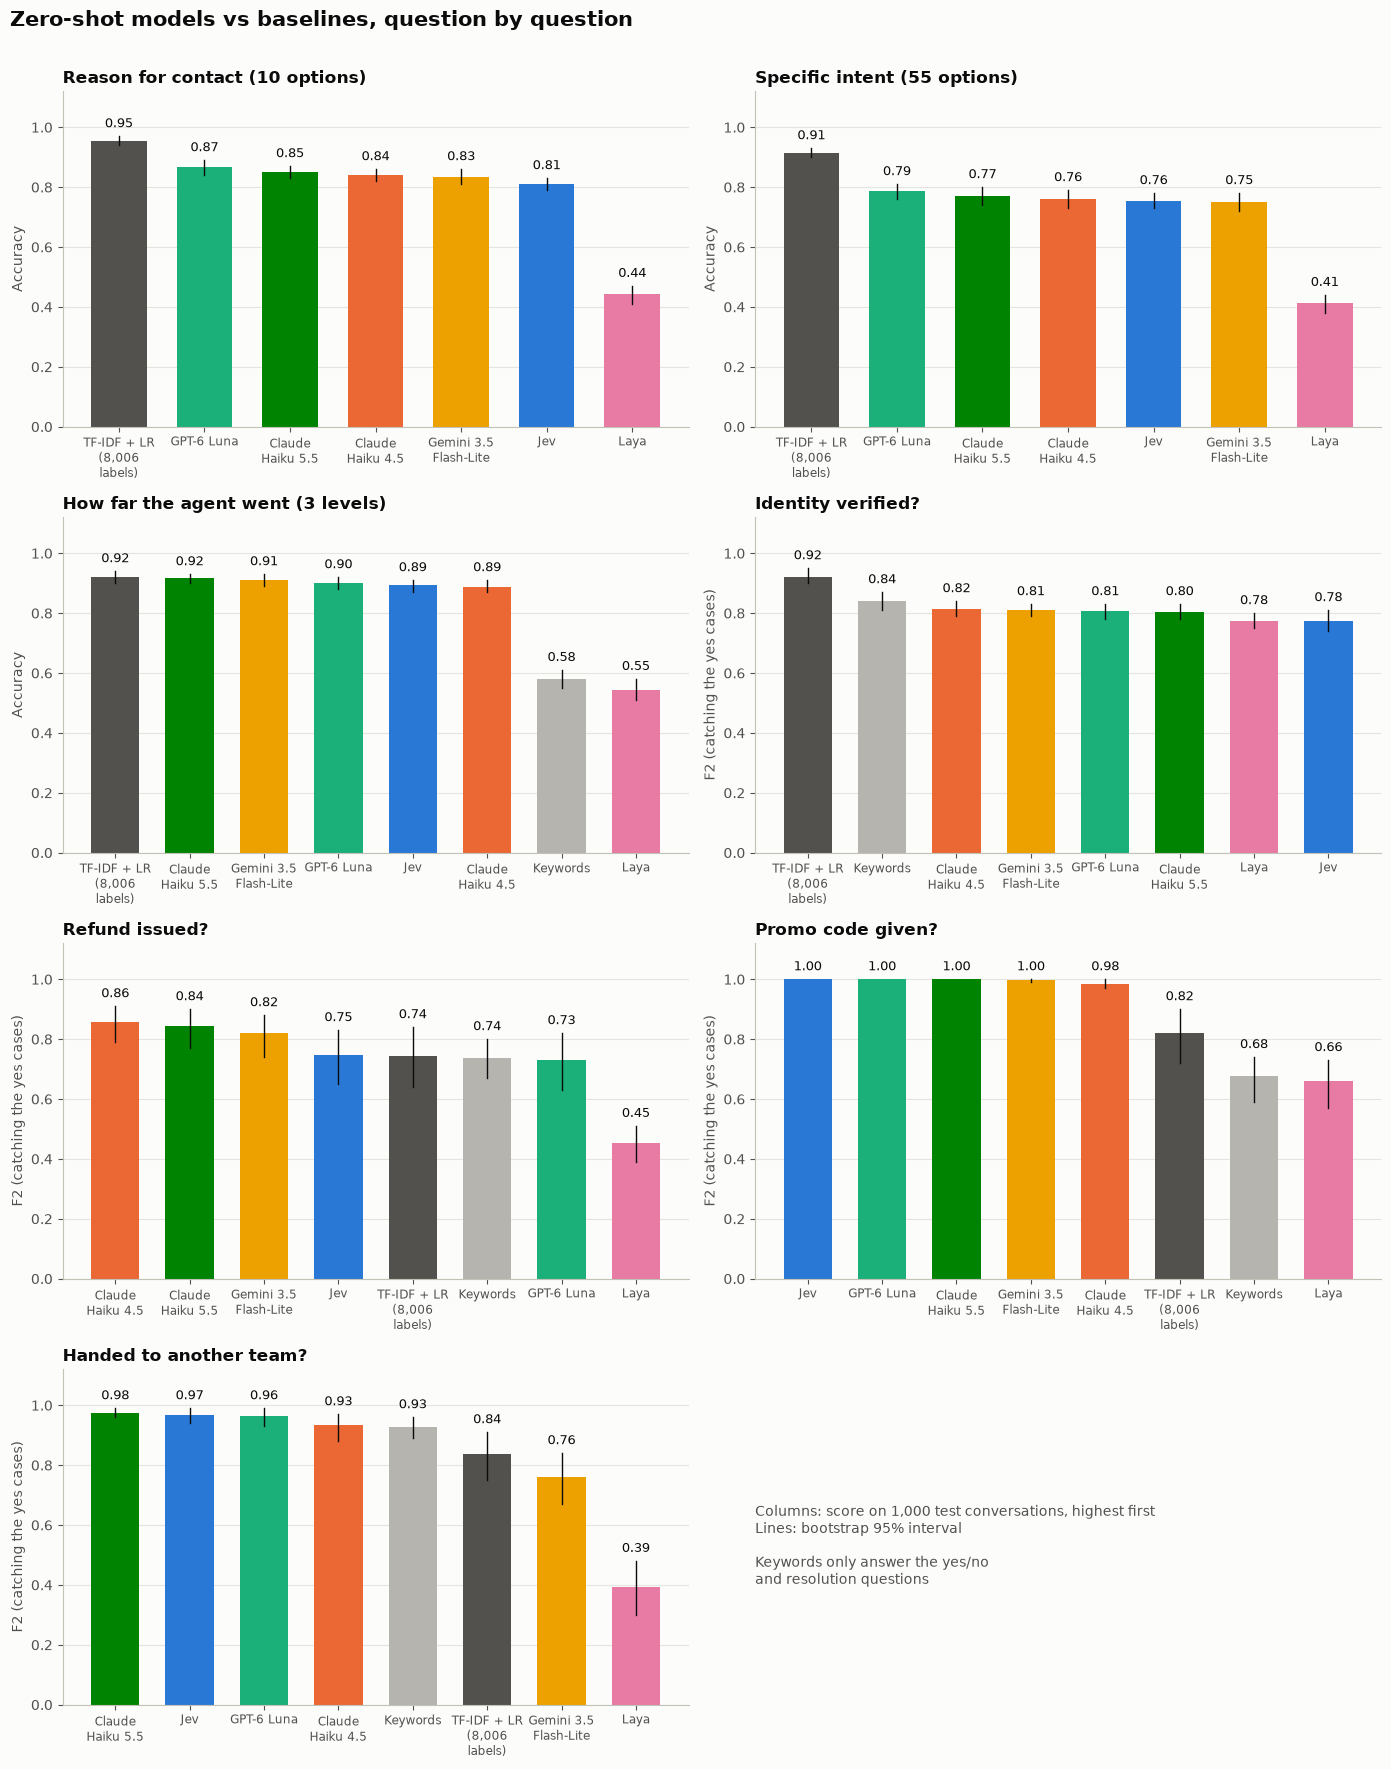

saved figures\03_scores_by_question.png


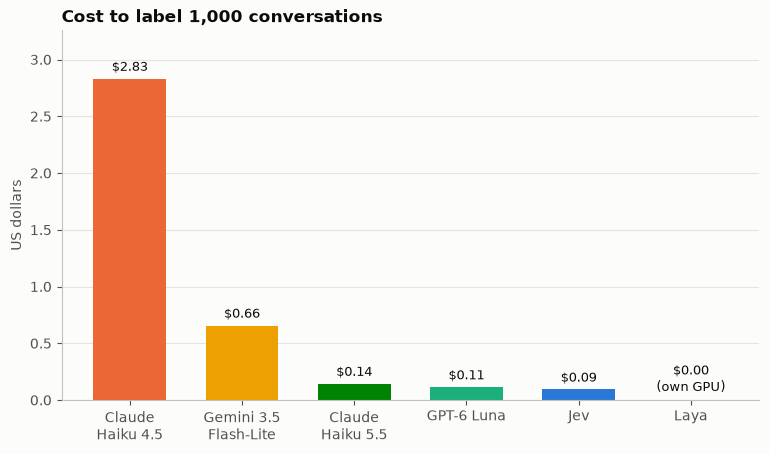

saved figures\04_cost_per_1000.png


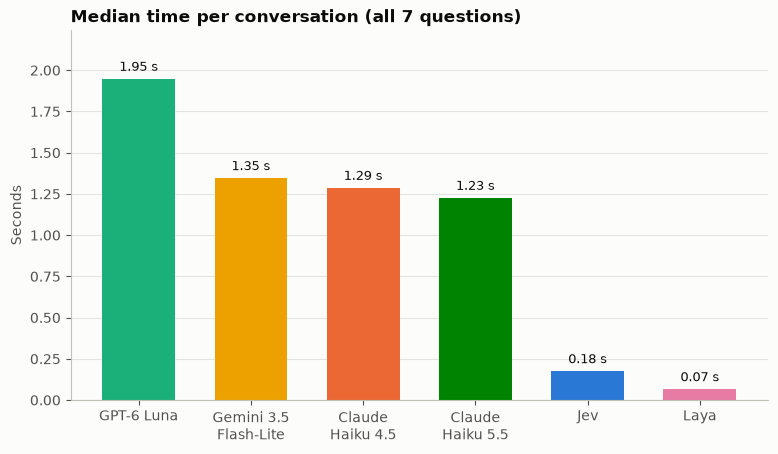

saved figures\05_latency.png


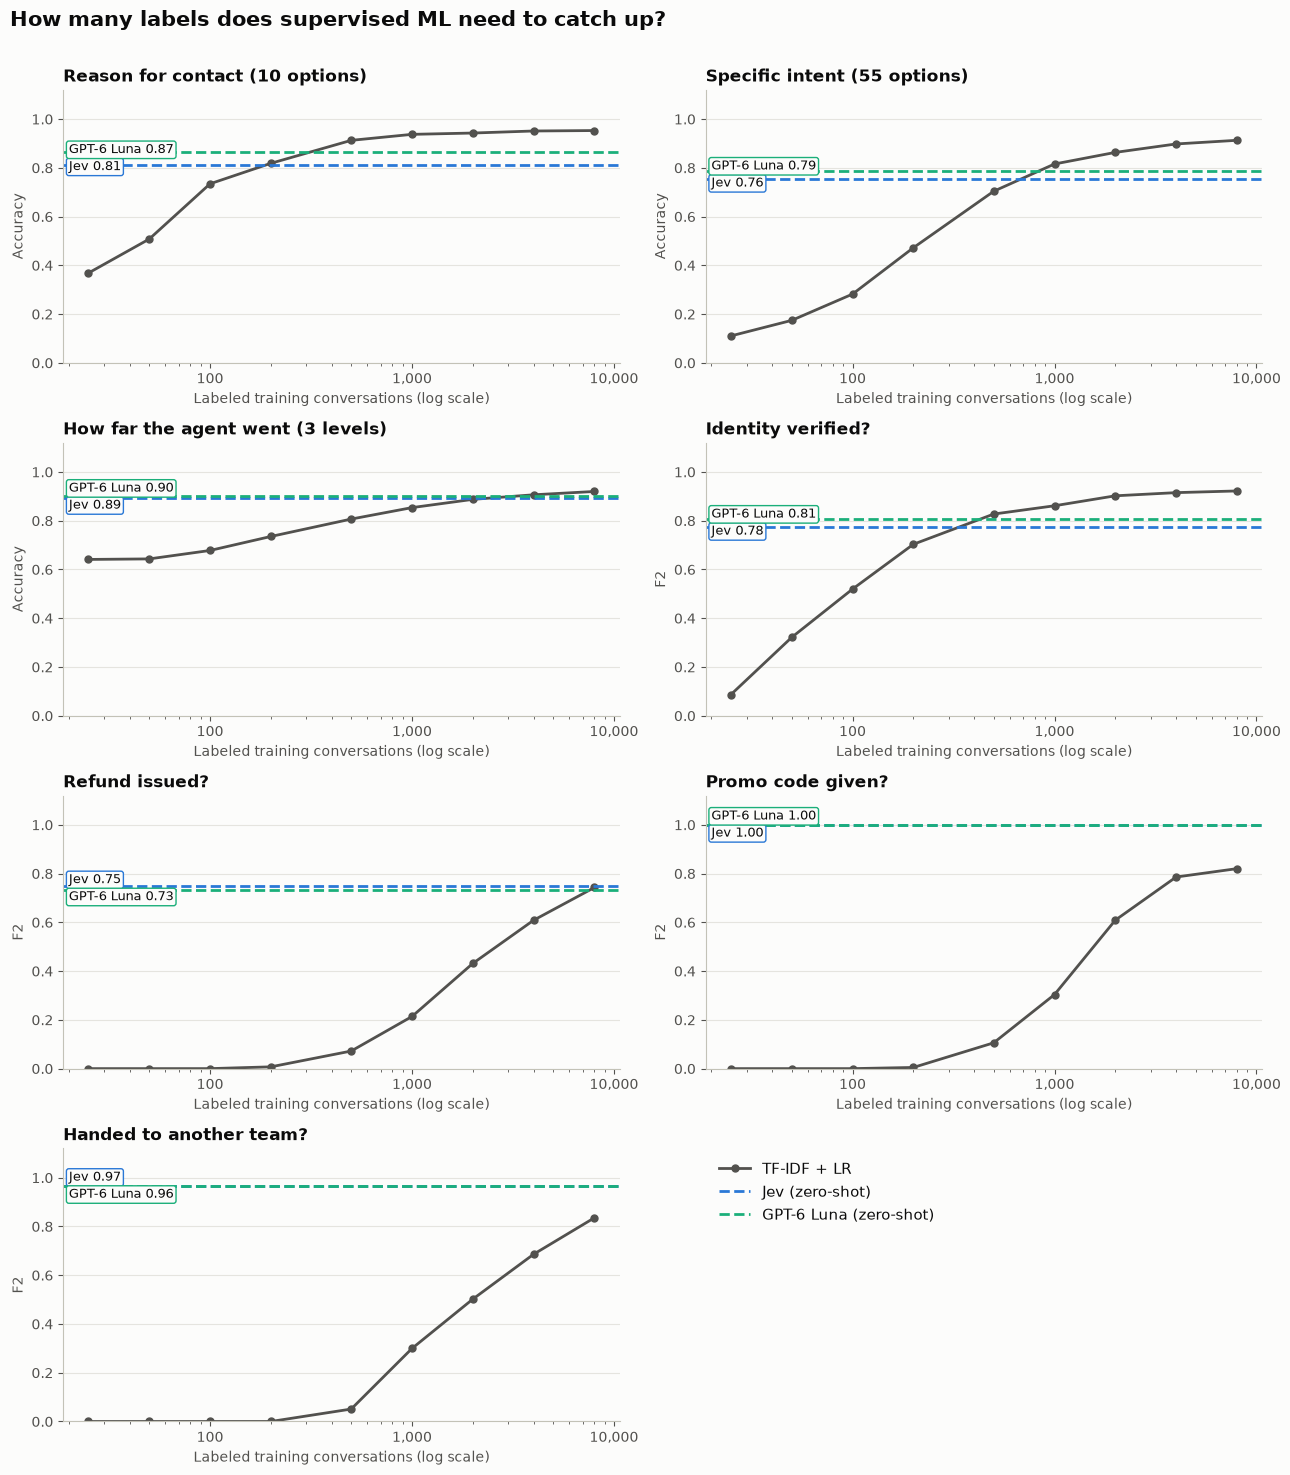

saved figures\06_learning_curve.png


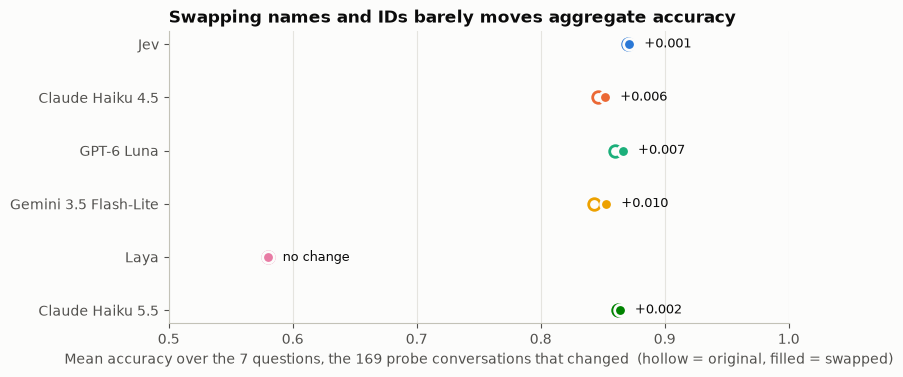

saved figures\07_memorization_probe.png


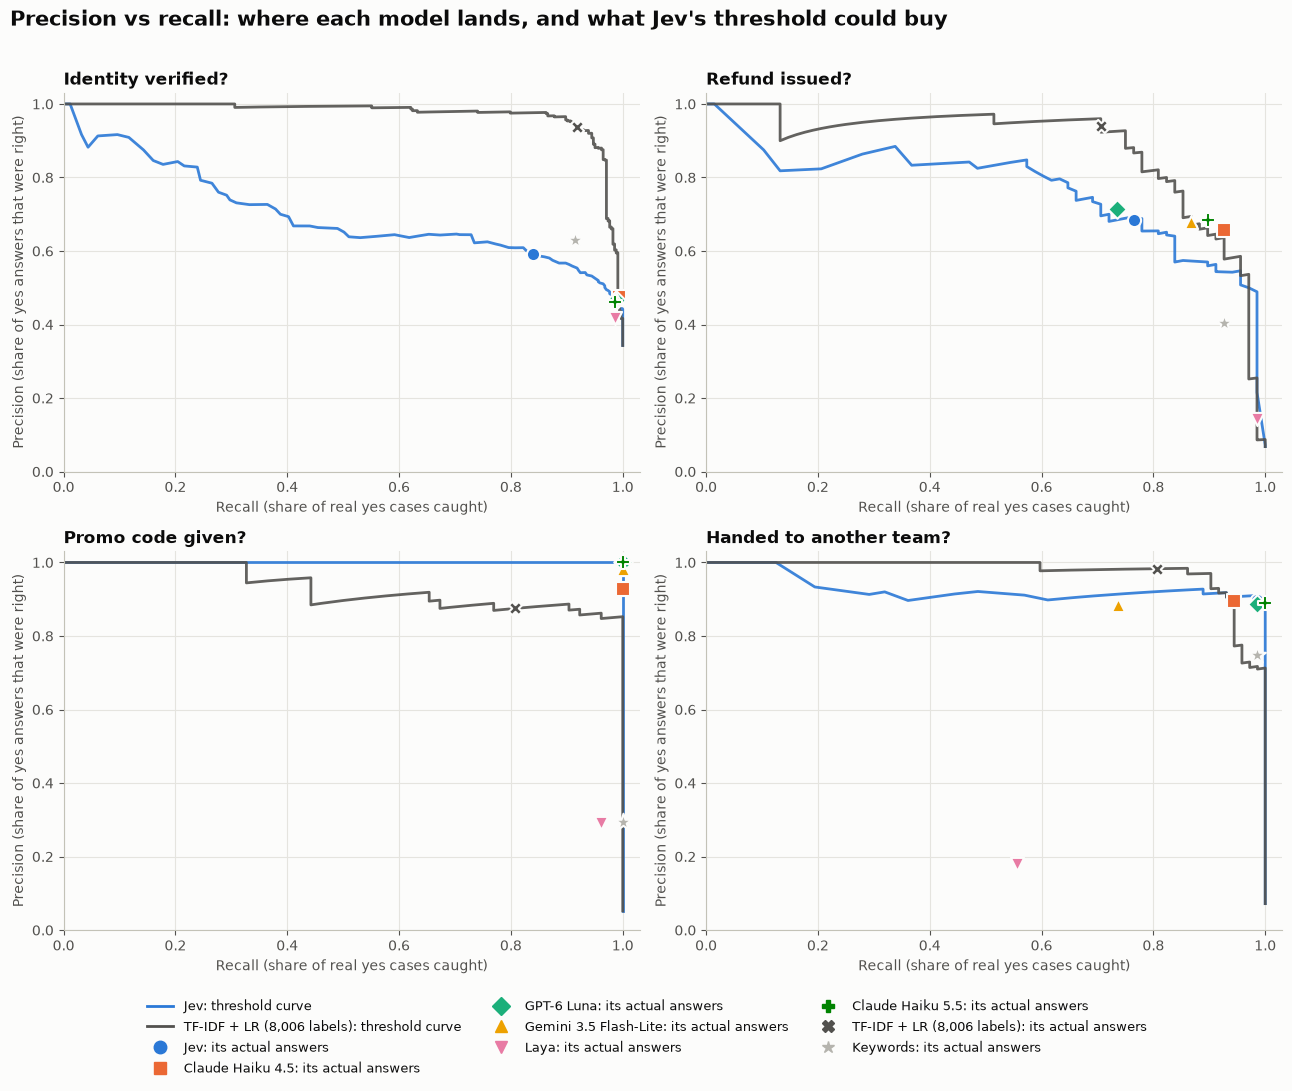

saved figures\08_precision_recall.png


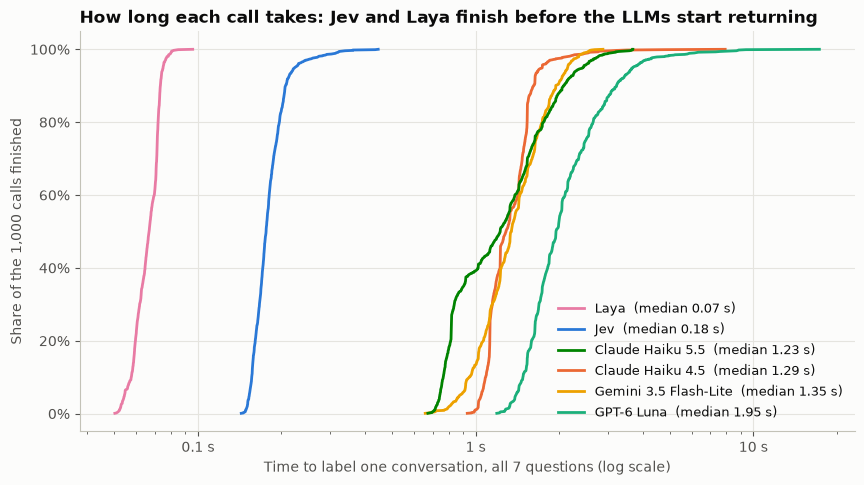

saved figures\09_latency_distribution.png


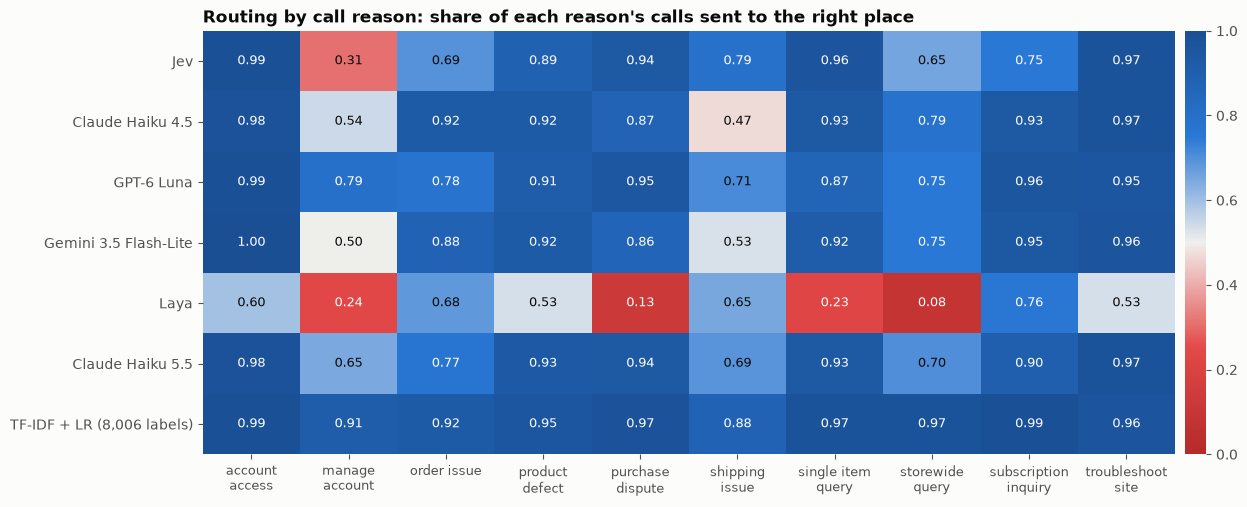

saved figures\10_reason_routing.png


In [19]:
import math

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(exist_ok=True)
INK, MUTED_INK, AXIS, GRID, SURFACE = "#0b0b0b", "#52514e", "#c3c2b7", "#e5e4df", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": AXIS, "axes.labelcolor": MUTED_INK, "xtick.color": MUTED_INK, "ytick.color": MUTED_INK,
    "text.color": INK, "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 10, "legend.frameon": False,
})

# Fixed slot order from the validated reference palette (validator: all checks pass in this order)
MODEL_COLORS = {
    "Jev": "#2a78d6", "Claude Haiku 4.5": "#eb6834", "GPT-6 Luna": "#1baf7a",
    "Gemini 3.5 Flash-Lite": "#eda100", "Laya (512)": "#e87ba4", "Claude Haiku 5.5": "#008300",
    SUPERVISED: "#52514e", "Keywords": "#b5b4ae",
}
DISPLAY_NAMES = {SUPERVISED: f"TF-IDF + LR ({len(train):,} labels)", "Laya (512)": "Laya"}
CHART_MODELS = [model for model in MODEL_COLORS if model in scores]   # baselines last, fixed order
ZERO_SHOT_CHART_MODELS = [model for model in CHART_MODELS if model in MODELS]
QUESTION_TITLES = {
    "reason": "Reason for contact (10 options)", "intent": "Specific intent (55 options)",
    "resolution": "How far the agent went (3 levels)", "identity_verified": "Identity verified?",
    "refund_offered": "Refund issued?", "promo_given": "Promo code given?", "handed_off": "Handed to another team?",
}

def display_name(model_name):
    return DISPLAY_NAMES.get(model_name, model_name)

def style_value_axis(ax, axis="x"):
    ax.grid(axis=axis, color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)

def save_figure(fig, name):
    path = FIGURES_DIR / f"{name}.png"
    fig.savefig(path, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"saved {path}")

# Column charts, tallest first. Colour still follows the model (never the rank), and every column is named
# and labelled with its value, so a reordering never leaves identity to colour alone.
import textwrap

def column_label(model_name):
    return textwrap.fill(display_name(model_name), 11)

# 3. Every question, every model: headline metric with its bootstrap 95% interval
fig, axes = plt.subplots(4, 2, figsize=(14, 18))
for ax, question in zip(axes.flat, QUESTION_TITLES):
    metric = headline_names[QUESTIONS[question]["type"]]
    models = [model for model in CHART_MODELS if question in scores[model]]
    models = sorted(models, key=lambda model: -scores[model][question][metric])   # stable: ties keep the fixed order
    values = [scores[model][question][metric] for model in models]
    intervals = [tuple(float(bound) for bound in scores[model][question]["95% CI"].split("-")) for model in models]
    ax.bar(range(len(models)), values, width=0.65, color=[MODEL_COLORS[model] for model in models])
    for x, (value, (low, high)) in enumerate(zip(values, intervals)):
        ax.plot([x, x], [low, high], color=INK, linewidth=1)
        ax.text(x, max(high, value) + 0.02, f"{value:.2f}", ha="center", va="bottom", color=INK, fontsize=9)
    ax.set_xticks(range(len(models)), [column_label(model) for model in models], fontsize=8.5)
    ax.set_ylim(0, 1.12)
    ax.set_title(QUESTION_TITLES[question])
    ax.set_ylabel("Accuracy" if metric == "accuracy" else "F2 (catching the yes cases)")
    style_value_axis(ax, "y")
axes.flat[-1].axis("off")
axes.flat[-1].text(0, 0.6, "Columns: score on 1,000 test conversations, highest first\nLines: bootstrap 95% interval\n\nKeywords only answer the yes/no\nand resolution questions",
                   color=MUTED_INK, fontsize=10, va="top")
fig.suptitle("Zero-shot models vs baselines, question by question", x=0.01, ha="left", fontsize=15, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.975))
save_figure(fig, "03_scores_by_question")

# 4 and 5. Cost and latency per model (zero-shot models only; one measure per chart, no shared axis), highest first
for figure_name, column, title, label, formatter in [
    ("04_cost_per_1000", "cost per 1,000 conversations $", "Cost to label 1,000 conversations", "US dollars", lambda v: f"${v:,.2f}"),
    ("05_latency", "median latency s", "Median time per conversation (all 7 questions)", "Seconds", lambda v: f"{v:.2f} s"),
]:
    ordered = efficiency_table.loc[[model for model in ZERO_SHOT_CHART_MODELS if model in efficiency_table.index], column].astype(float)
    ordered = ordered.sort_values(ascending=False, kind="stable")
    fig, ax = plt.subplots(figsize=(9, 4.8))
    ax.bar(range(len(ordered)), ordered.values, width=0.65, color=[MODEL_COLORS[model] for model in ordered.index])
    for x, value in enumerate(ordered.values):
        ax.text(x, value + ordered.max() * 0.015, formatter(value) + ("\n(own GPU)" if value == 0 and column.startswith("cost") else ""),
                ha="center", va="bottom", color=INK, fontsize=9)
    ax.set_xticks(range(len(ordered)), [column_label(model) for model in ordered.index])
    ax.set_ylim(0, ordered.max() * 1.15)
    ax.set_title(title)
    ax.set_ylabel(label)
    style_value_axis(ax, "y")
    save_figure(fig, figure_name)

# 6. Learning curve: the supervised model's score by training-set size, with each zero-shot model as a reference line
fig, axes = plt.subplots(4, 2, figsize=(13, 15))
for ax, question in zip(axes.flat, QUESTION_TITLES):
    metric = headline_names[QUESTIONS[question]["type"]]
    curve = learning_curve.loc[question]
    ax.plot(curve.index, curve.values, color=MODEL_COLORS[SUPERVISED], linewidth=2, marker="o", markersize=5, label=display_name(SUPERVISED).split(" (")[0])
    reference_values = {model: scores[model][question][metric] for model in ["Jev", "GPT-6 Luna"] if model in scores}
    for model, value in reference_values.items():
        ax.axhline(value, color=MODEL_COLORS[model], linewidth=2, linestyle="--", label=f"{model} (zero-shot)")
    # Direct labels at the left edge; nudge apart when the two lines (nearly) coincide so both stay readable
    label_positions = dict(reference_values)
    if len(reference_values) == 2 and abs(max(reference_values.values()) - min(reference_values.values())) < 0.06:
        low_model, high_model = sorted(reference_values, key=reference_values.get)
        middle = (reference_values[low_model] + reference_values[high_model]) / 2
        label_positions = {low_model: middle - 0.035, high_model: middle + 0.035}
    for model, value in reference_values.items():
        ax.text(20, label_positions.get(model, value), f"{model} {value:.2f}", color=INK, fontsize=9, va="center",
                bbox={"facecolor": SURFACE, "edgecolor": MODEL_COLORS[model], "boxstyle": "round,pad=0.2"})
    ax.set_xscale("log")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda value, _: f"{value:,.0f}"))
    ax.set_ylim(0, 1.12)
    ax.set_title(QUESTION_TITLES[question])
    ax.set_xlabel("Labeled training conversations (log scale)")
    ax.set_ylabel("Accuracy" if metric == "accuracy" else "F2")
    style_value_axis(ax, "y")
handles, labels = axes.flat[0].get_legend_handles_labels()
axes.flat[-1].axis("off")
axes.flat[-1].legend(handles, labels, loc="upper left", fontsize=11)
fig.suptitle("How many labels does supervised ML need to catch up?", x=0.01, ha="left", fontsize=15, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.975))
save_figure(fig, "06_learning_curve")

# 7. Memorization probe: mean accuracy over the 7 questions, original vs identifying details swapped
probe_table = pd.DataFrame(probe_results).T
probe_models = [model for model in ZERO_SHOT_CHART_MODELS if model in probe_table.index][::-1]
fig, ax = plt.subplots(figsize=(8, 3.8))
for y, model in enumerate(probe_models):
    original, swapped = probe_table.loc[model, "mean accuracy, original"], probe_table.loc[model, "mean accuracy, details swapped"]
    ax.plot([original, swapped], [y, y], color=AXIS, linewidth=2, zorder=1)
    ax.scatter(original, y, s=70, facecolor=SURFACE, edgecolor=MODEL_COLORS[model], linewidth=2, zorder=2)
    ax.scatter(swapped, y, s=70, color=MODEL_COLORS[model], edgecolor=SURFACE, linewidth=2, zorder=3)
    change = swapped - original
    ax.text(max(original, swapped) + 0.012, y, "no change" if abs(change) < 0.0005 else f"{change:+.3f}", va="center", color=INK, fontsize=9)
ax.set_yticks(range(len(probe_models)), [display_name(model) for model in probe_models])
ax.set_xlim(0.5, 1.0)
ax.set_title("Swapping names and IDs barely moves aggregate accuracy")
ax.set_xlabel(f"Mean accuracy over the 7 questions, the {len(changed_ids)} probe conversations that changed  (hollow = original, filled = swapped)")
style_value_axis(ax)
save_figure(fig, "07_memorization_probe")

# 8. Precision vs recall per yes/no label. Curves = models with probabilities (move the threshold, slide along the
# curve); markers = every model at its actual 0.5 / yes-no operating point. Marker shape doubles colour as identity.
MARKERS = {"Jev": "o", "Claude Haiku 4.5": "s", "GPT-6 Luna": "D", "Gemini 3.5 Flash-Lite": "^", "Laya (512)": "v",
           "Claude Haiku 5.5": "P", SUPERVISED: "X", "Keywords": "*"}
MARKER_SIZES = {"Keywords": 160}
fig, axes = plt.subplots(2, 2, figsize=(13, 11))
for ax, question in zip(axes.flat, NOUL_QUESTIONS):
    truth = test[question].values.astype(bool)
    for model_name in ["Jev", SUPERVISED]:
        precision, recall, _ = precision_recall_curve(truth, all_probabilities[model_name][question])
        ax.plot(recall, precision, color=MODEL_COLORS[model_name], linewidth=2, alpha=0.9, zorder=1)
    for model_name in CHART_MODELS:
        if question in scores[model_name]:
            point = scores[model_name][question]
            ax.scatter(point["recall"], point["precision"], s=MARKER_SIZES.get(model_name, 90), marker=MARKERS[model_name], color=MODEL_COLORS[model_name],
                       edgecolor=SURFACE, linewidth=1.5, zorder=3)
    ax.set_xlim(0, 1.03)
    ax.set_ylim(0, 1.03)
    ax.set_xlabel("Recall (share of real yes cases caught)")
    ax.set_ylabel("Precision (share of yes answers that were right)")
    ax.set_title(QUESTION_TITLES[question])
    ax.grid(color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
handles = [plt.Line2D([], [], color=MODEL_COLORS[model], linewidth=2, label=f"{display_name(model)}: threshold curve")
           for model in ["Jev", SUPERVISED]]
handles += [plt.Line2D([], [], linestyle="", marker=MARKERS[model], markersize=9, color=MODEL_COLORS[model],
                       label=f"{display_name(model)}: its actual answers") for model in CHART_MODELS]
fig.suptitle("Precision vs recall: where each model lands, and what Jev's threshold could buy", x=0.01, ha="left", fontsize=15, fontweight="bold")
fig.tight_layout(rect=(0, 0.09, 1, 0.97))
fig.legend(handles=handles, loc="lower center", ncol=3, fontsize=9.5, bbox_to_anchor=(0.5, 0.0))
save_figure(fig, "08_precision_recall")

# 9. Latency: the distribution of every call, not just the median. Cumulative share of calls finished by time t.
latency_models = [model for model in ZERO_SHOT_CHART_MODELS if model in efficiency_table.index]
all_calls = {model: collect_calls for model, (_, _, collect_calls) in collect().items()}
fig, ax = plt.subplots(figsize=(10, 5.2))
for model_name in latency_models:
    latencies = np.sort(all_calls[model_name]["latency_s"].astype(float).values)
    share = np.arange(1, len(latencies) + 1) / len(latencies)
    median = np.median(latencies)
    ax.plot(latencies, share, color=MODEL_COLORS[model_name], linewidth=2,
            label=f"{display_name(model_name)}  (median {median:.2f} s)")
ax.set_xscale("log")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda value, _: f"{value:g} s"))
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0, decimals=0))
ax.set_xlabel("Time to label one conversation, all 7 questions (log scale)")
ax.set_ylabel("Share of the 1,000 calls finished")
ax.set_title("How long each call takes: Jev and Laya finish before the LLMs start returning")
handles, labels = ax.get_legend_handles_labels()
order = np.argsort([float(label.split("median ")[1].split(" s")[0]) for label in labels])   # fastest first, matching left to right
ax.legend([handles[i] for i in order], [labels[i] for i in order], loc="lower right", fontsize=9.5)
ax.grid(color=GRID, linewidth=0.8)
ax.set_axisbelow(True)
save_figure(fig, "09_latency_distribution")

# 10. Routing by call reason: share of each reason's calls labelled with the right reason (per-class recall)
routing_models = [model for model in CHART_MODELS if "reason" in scores[model]]
reasons = list(FLOW_DESCRIPTIONS)
routing = pd.DataFrame({model: [np.mean(all_predictions[model]["reason"][test["reason"].values == reason] == reason) for reason in reasons]
                        for model in routing_models}, index=reasons).T
fig, ax = plt.subplots(figsize=(13, 5.5))
# Diverging red <-> blue from the reference palette, neutral grey at 0.5: misrouting reads as red, good routing as blue
from matplotlib.colors import LinearSegmentedColormap
routing_cmap = LinearSegmentedColormap.from_list("routing", ["#b52a2a", "#e34948", "#f0efec", "#2a78d6", "#1a4f94"])
image = ax.imshow(routing.values, cmap=routing_cmap, vmin=0, vmax=1, aspect="auto")
for (row, col), value in np.ndenumerate(routing.values):
    ax.text(col, row, f"{value:.2f}", ha="center", va="center", fontsize=9, color=SURFACE if abs(value - 0.5) > 0.24 else INK)
ax.set_xticks(range(len(reasons)), [textwrap.fill(reason.replace("_", " "), 12, break_long_words=False) for reason in reasons], fontsize=9)
ax.set_yticks(range(len(routing_models)), [display_name(model) for model in routing_models])
ax.set_title("Routing by call reason: share of each reason's calls sent to the right place")
for spine in ax.spines.values():
    spine.set_visible(False)
fig.colorbar(image, ax=ax, fraction=0.025, pad=0.01).outline.set_visible(False)
save_figure(fig, "10_reason_routing")

## Caveats

- **Role-played data.** ABCD conversations are crowdworkers following scripts, typed in chat. The commercially usable real call corpora don't exist; the principle being tested is labeling conversations, not the realness of the set.
- **The identity question measures wording, not reading.** Both Haikus, Luna, Flash-Lite and Laya each flag 378-471 false alarms: they read "the agent asked for my details" as "the agent verified my identity", while the ground truth is the agent clicking `verify-identity`. Jev flags fewer (198) but misses more (55, against 2-5 for the others). A regex beat every zero-shot model on F2. More generally, the yes/no labels measure logged system events, not everything a person would call a refund or a handoff. The question stays as frozen, and the lesson is real: zero-shot labels are only as good as the definition, and a label tied to a system event needs the event described precisely.
- **Cheap LLMs are close to Jev on price, not just on accuracy.** GPT-6 Luna cost $0.11 per 1,000 conversations against Jev's $0.09, because 87% of its input was a cache hit on the shared question block. Without caching it would be roughly twice that. Claude Haiku 5.5 lands at $0.14 with an 89% cache hit, a 20x drop from Haiku 4.5, which can't cache a prompt this short (4,096-token minimum) and is the most expensive at $2.83.
- **Some zero-shot gaps are real, most are not.** Overlapping per-model intervals hid this; the paired comparisons against Jev settle it. Surviving the correction for running every comparison: GPT-6 Luna beats Jev on call reason (+5.4 points), Claude Haiku 5.5 beats it on call reason (+4.0) and resolution (+2.3), Gemini Flash-Lite trails Jev on handoffs (-20.6 F2 points) and edges it on resolution (+1.9), and Laya trails Jev on everything except the identity question. Clear only at the uncorrected 95% level, so suggestive rather than settled: Luna on intent (+3.3), both Haikus on refunds (+10.9 and +9.8), Haiku 4.5 on reason (+3.0), and small identity edges for Haiku 4.5, Luna and Flash-Lite. Everything else, including every promo-code result, can't be told apart. These are comparisons against Jev only; the LLMs were not compared with each other.
- **Laya is not a fair zero-shot contender, by its own docs.** The base checkpoint is documented as near chance zero-shot and meant to be fine-tuned; this run confirms that. Its load also warns that the shipped calibration temperatures are out of range, so its probabilities are uncalibrated. Its 70 ms latency is what fine-tuning would buy.
- **Keyword regexes were written after looking at the whole dataset**, test split included, in `01_explore.ipynb`. The keyword baseline is exploratory, not a clean holdout, and if anything slightly flattered.
- **Memorization is tested, not ruled out.** On the 169 probe conversations that contained identifying details, swapping them moved no model's mean accuracy by a detectable amount (every paired interval includes zero), but individual labels did flip: 12 of 1,183 for Jev, 16-42 for the LLMs (Haiku 5.5 the fewest), 53-71 for Laya. Without the repeat control, those flips can't be split between the swap and ordinary run-to-run variation. Structure and wording stay recognizable, so a model could still recognize a conversation.
- **Costs are logged tokens x configured prices**, checked against each provider's pricing page on 2026-09-28 (Haiku 5.5 on 2026-10-08), not against invoices. The log keeps each provider's reported usage and model name, not the complete raw response, so billing and the serving backend can't be independently authenticated from the CSV alone.
- **Perfect scores have degenerate intervals.** The 1.00 F2 on promo codes from Jev, Luna and Haiku 5.5 means no miss among 52 positives in this test set, not zero miss rate.
- **Option descriptions are one honest attempt**, identical for every model. Better descriptions would likely help every zero-shot model; they were not tuned on test results.
- **Reasoning at provider defaults.** Luna used ~87 reasoning tokens per call by default; Haiku 4.5 and Flash-Lite used none. Haiku 5.5 thinks by default (adaptive, effort medium): its 158 output tokens per call against Haiku 4.5's 58 are mostly thinking, but Anthropic's usage doesn't break thinking out, so its "reasoning tokens" column reads 0. "Out of the box" is not "each model at its best".
- **The cloud LLMs aren't deterministic**; the attrition run saw F2 move by 0.07 between identical runs. Jev returned identical probabilities on every repeat there.
- **Latency is one sequential call at a time** from one home connection, and Laya's is on a local RTX 5070 Ti with no network. Parallel throughput is a separate experiment.
- **Token counts aren't comparable across vendors.** Compare cost and latency.